 EDA para o Problema da Minerva

## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


import matplotlib.cm as cm
import matplotlib.colors as mcolors

import statsmodels.api as sm
import numpy as np
import pandas as pd


In [2]:
# ---------------------------------------------------------
# CONFIGURAÇÃO DO DIRETÓRIO RAIZ
# ---------------------------------------------------------
# Verifica se a pasta 'data' existe no diretório atual. 
# Se não existir, ele assume que estamos na pasta 'notebook' e sobe um nível ('..')
if not os.path.isdir('data'):
    os.chdir('..')

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")

Diretório de trabalho atualizado para: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/2026_resolucao_problemas


In [3]:
file_path = 'data/raw/instance_desafio_minerva.xlsx'

## Leitura dos dados

In [4]:
df = pd.read_excel(file_path, sheet_name='base_dados')

In [5]:
df.head()

,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$)
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805


In [6]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Produto                 86 non-null     str           
 1   Data                    86 non-null     datetime64[us]
 2   Volume Realizado (kg)   86 non-null     float64       
 3   Receita Realizada (R$)  86 non-null     float64       
 4   Custo Realizado (R$)    86 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 3.5 KB


None

In [7]:
# 1. Garantir que a Data é do tipo datetime
df['Data'] = pd.to_datetime(df['Data'])

# 2. Extrair o Dia da Semana e mapear para nomes
dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 
            4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['Dia da Semana'] = df['Data'].dt.dayofweek.map(dias_map)

# 3. Calcular Variáveis Unitárias
df['Preço'] = df['Receita Realizada (R$)'] / df['Volume Realizado (kg)']
df['Custo Realizado (R$/kg)'] = df['Custo Realizado (R$)'] / df['Volume Realizado (kg)']

# Visualização inicial para confirmar
display(df.head())

,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$),Dia da Semana,Preço,Custo Realizado (R$/kg)
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571,Sexta,1267.949227,983.791250
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770,Segunda,1279.335771,984.906501
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598,Terça,1258.408986,985.657521
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597,Quarta,1241.133798,984.567075
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805,Quinta,1253.118993,987.177524


### ⚠️ Melhoria 1 — Cuidado: o que a variável `Preço` realmente representa

`Preço = Receita / Volume` é o **preço médio realizado no dia**, não necessariamente o preço
de tabela que foi decidido antes da venda. Se clientes grandes negociam desconto por volume
(comum em relações B2B), um dia com "preço baixo e volume alto" pode significar o contrário
do que parece: o pedido grande **causou** o desconto, e não o desconto que causou o pedido grande.

Isso se chama **causalidade reversa / endogeneidade** — quando a variável explicativa (preço) e a
variável resposta (volume) se influenciam mutuamente. Se isso estiver acontecendo, a elasticidade
que vamos estimar mais adiante fica **inflada** (mais negativa do que a realidade).

Não temos dados de pedido individual para confirmar isso diretamente, mas um teste indireto
útil é: será que a correlação negativa entre preço e volume é forte mesmo **dentro do mesmo
dia da semana** (não só quando comparamos, por ex., Segunda com Sexta)? Se for forte mesmo
dentro do grupo, é um indício de que existe sensibilidade real ao preço, e não só um efeito
de nível entre dias diferentes.

In [8]:
# Correlação entre Preço e Volume, olhando DENTRO de cada dia da semana
# (em vez de misturar todos os dias, o que poderia mascarar o efeito real do preço)
ordem_dias_corr = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

corr_por_dia = df.groupby('Dia da Semana').apply(
    lambda g: g['Preço'].corr(g['Volume Realizado (kg)'])
).reindex(ordem_dias_corr)

print("Correlação Preço x Volume, dentro de cada dia da semana:")
print(corr_por_dia.round(2))
print()
print("Se os valores forem consistentemente negativos e fortes (< -0.5) em quase todos os")
print("dias, é um bom sinal de que existe sensibilidade real ao preço (não é só um artefato")
print("da diferença de nível entre dias). Se forem fracos ou inconsistentes, desconfie da elasticidade.")

Correlação Preço x Volume, dentro de cada dia da semana:
Dia da Semana
Segunda   -0.77
Terça     -0.74
Quarta    -0.64
Quinta    -0.83
Sexta     -0.66
Sábado     0.86
Domingo   -0.45
dtype: float64

Se os valores forem consistentemente negativos e fortes (< -0.5) em quase todos os
dias, é um bom sinal de que existe sensibilidade real ao preço (não é só um artefato
da diferença de nível entre dias). Se forem fracos ou inconsistentes, desconfie da elasticidade.


## Separar em teste e treino
- Definido por regra que o treino é até dia 31/10/2025 (inclusive)

In [9]:
data_corte = pd.to_datetime('2025-10-31')

# Treino: Dados até 31/10/2025 (inclusive)
df_treino_raw = df[df['Data'] <= data_corte].copy()

# Teste: Dados a partir de 01/11/2025
df_teste_raw = df[df['Data'] > data_corte].copy()

print(f"Período de Treino: {df_treino_raw['Data'].min().date()} até {df_treino_raw['Data'].max().date()}")
print(f"Período de Teste: {df_teste_raw['Data'].min().date()} até {df_teste_raw['Data'].max().date()}\n")

print(f"Tamanho da base de Treino: {df_treino_raw.shape[0]} dias")
print(f"Tamanho da base de Teste: {df_teste_raw.shape[0]} dias")

Período de Treino: 2025-08-01 até 2025-10-31
Período de Teste: 2025-11-03 até 2025-11-14

Tamanho da base de Treino: 76 dias
Tamanho da base de Teste: 10 dias


### Salvar split

In [10]:
caminho_interim = 'data/interim/'
caminho_teste = caminho_interim + '.teste.csv'
caminho_treino = caminho_interim + '.treino.csv'

In [11]:
df_treino_raw.to_csv(caminho_treino, index=False)
df_teste_raw.to_csv(caminho_teste, index=False)


# Descritiva

## Estatística Descritiva (Treino)

In [12]:
# ler treino do interim e trata data como datetipe
df_treino = pd.read_csv(caminho_treino, parse_dates=['Data'])

In [13]:
# Cálculo da Margem (Receita - Custo)
df_treino['Margem'] = df_treino['Receita Realizada (R$)'] - df_treino['Custo Realizado (R$)']

# Seleção das colunas numéricas de interesse
cols_analise = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem']

# Geração da tabela descritiva (transposta para melhor visualização)
descritiva = df_treino[cols_analise].describe().T
descritiva['Coef_Variacao (%)'] = (descritiva['std'] / descritiva['mean']) * 100

print("Estatística Descritiva (Base de Treino Oficial - Até 31/10/2025):")
display(descritiva.round(2))

Estatística Descritiva (Base de Treino Oficial - Até 31/10/2025):


,count,mean,std,min,25%,50%,75%,max,Coef_Variacao (%)
Volume Realizado (kg),76.0,21.13,18.94,0.59,7.60,16.70,28.45,100.00,89.65
Preço,76.0,1275.02,39.23,1188.86,1245.92,1276.49,1298.94,1365.49,3.08
Custo Realizado (R$/kg),76.0,981.63,12.96,949.12,973.95,983.67,986.24,1030.34,1.32
Margem,76.0,5862.31,4526.00,123.89,2107.49,5280.24,8061.05,21571.06,77.21


## ⚠️ Melhoria 2 — Visão Cronológica (o padrão é estável ao longo do tempo?)

Até aqui, os dados só foram olhados **agrupados** (por dia da semana, por quinzena, por mês).
Isso é ótimo para comparar categorias, mas pode esconder uma coisa importante: será que o
comportamento de uma Segunda-feira de agosto é igual ao de uma Segunda-feira de outubro?
Ou existe uma tendência (volume subindo ou caindo mês a mês) que os gráficos agrupados
não deixam ver?

Também vale confirmar visualmente uma premissa que estamos assumindo: que o **custo por kg**
é praticamente constante (a estatística descritiva já mostrou CV de ~1%, mas nunca vimos o
gráfico). Isso importa porque toda a conta de margem (`Preço - Custo`) depende dessa premissa.

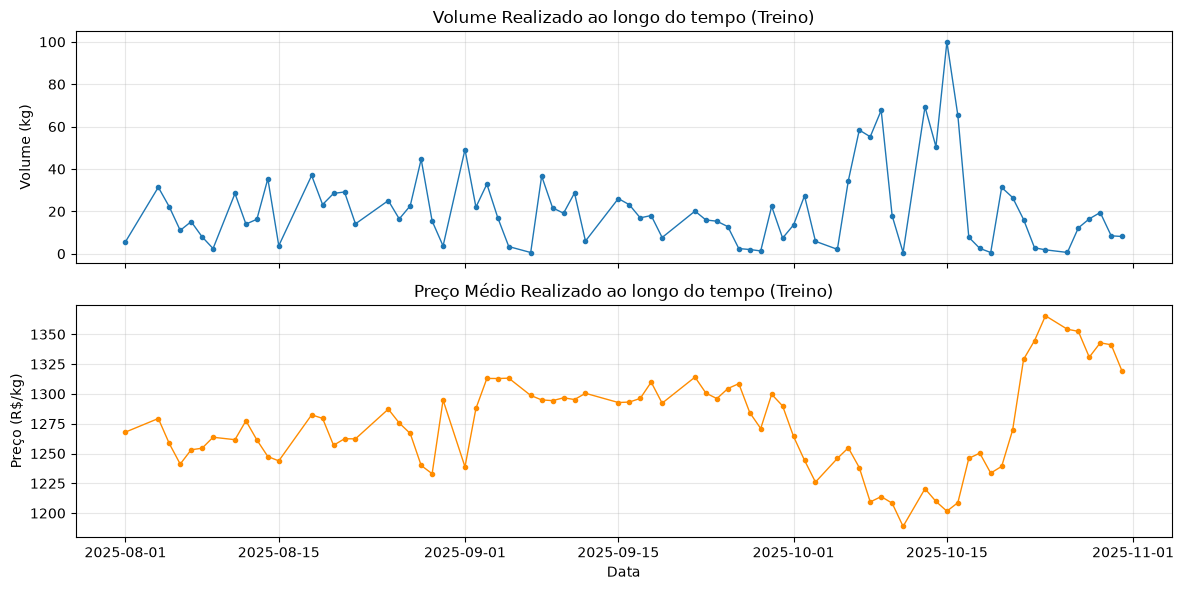

O que observar: existe uma tendência de subida/descida ao longo dos 3 meses?
Se sim, um modelo treinado com a 'média' do período inteiro pode já estar desatualizado.


In [14]:
# Linha do tempo de Volume e Preço, em ordem cronológica (sem agrupar por categoria)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_treino['Data'], df_treino['Volume Realizado (kg)'], marker='o', markersize=3, linewidth=1)
axes[0].set_title('Volume Realizado ao longo do tempo (Treino)')
axes[0].set_ylabel('Volume (kg)')
axes[0].grid(alpha=0.3)

axes[1].plot(df_treino['Data'], df_treino['Preço'], marker='o', markersize=3, linewidth=1, color='darkorange')
axes[1].set_title('Preço Médio Realizado ao longo do tempo (Treino)')
axes[1].set_ylabel('Preço (R$/kg)')
axes[1].set_xlabel('Data')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("O que observar: existe uma tendência de subida/descida ao longo dos 3 meses?")
print("Se sim, um modelo treinado com a 'média' do período inteiro pode já estar desatualizado.")

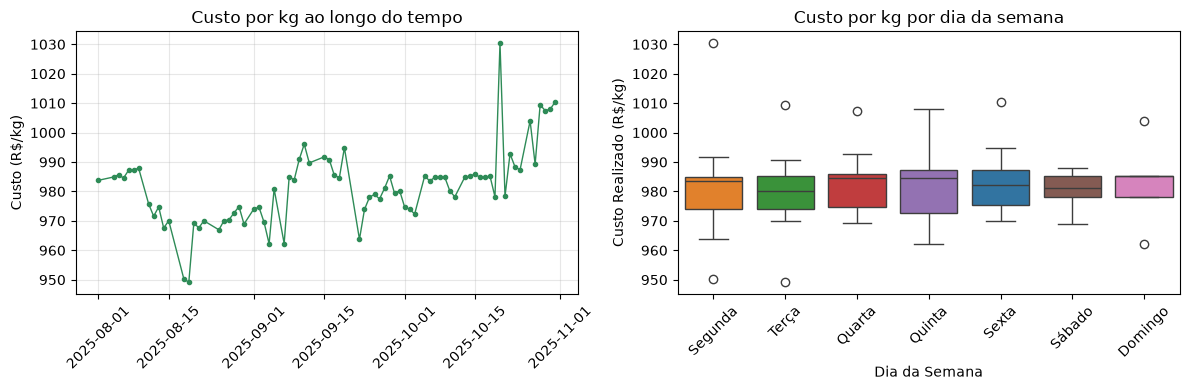

Se as caixas/linha forem parecidas entre si (sem padrão claro), a premissa de
'custo praticamente fixo' usada mais adiante na otimização de margem está confirmada.


In [15]:
# Estabilidade do custo por kg: ao longo do tempo e por dia da semana
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_treino['Data'], df_treino['Custo Realizado (R$/kg)'], marker='o', markersize=3, linewidth=1, color='seagreen')
axes[0].set_title('Custo por kg ao longo do tempo')
axes[0].set_ylabel('Custo (R$/kg)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
sns.boxplot(data=df_treino, x='Dia da Semana', y='Custo Realizado (R$/kg)', order=ordem_dias,
            ax=axes[1], hue='Dia da Semana', legend=False)
axes[1].set_title('Custo por kg por dia da semana')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Se as caixas/linha forem parecidas entre si (sem padrão claro), a premissa de")
print("'custo praticamente fixo' usada mais adiante na otimização de margem está confirmada.")

## Teste de hipóteses

In [16]:
# 1. Isolando apenas os dias úteis na base de treino
df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])].copy()

# 2. Transformação Logarítmica (Para a Curva de Elasticidade Log-Log)
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# 3. Criando Variáveis de Sazonalidade
df_uteis['Dia do Mês'] = df_uteis['Data'].dt.day

# -- Quinzena
df_uteis['Quinzena'] = np.where(df_uteis['Dia do Mês'] <= 15, '1ª Quinzena', '2ª Quinzena')

# -- Mês
mapa_meses = {8: 'Agosto', 9: 'Setembro', 10: 'Outubro'}
df_uteis['Mês'] = df_uteis['Data'].dt.month.map(mapa_meses)

# -- Semana do Mês (Lógica: dias 1-7=Sem1, 8-14=Sem2...)
df_uteis['Semana do Mês'] = (df_uteis['Dia do Mês'] - 1) // 7 + 1

print("Feature Engineering concluído com sucesso!")
df_uteis.head()

Feature Engineering concluído com sucesso!


,Produto,Data,Volume Realizado (kg),Receita Realizada (R$),Custo Realizado (R$),Dia da Semana,Preço,Custo Realizado (R$/kg),Margem,ln_Volume,ln_Preco,Dia do Mês,Quinzena,Mês,Semana do Mês
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571,Sexta,1267.949227,983.791250,1598.569081,1.727334,7.145156,1,1ª Quinzena,Agosto,1
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770,Segunda,1279.335771,984.906501,9242.270435,3.446504,7.154096,4,1ª Quinzena,Agosto,1
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598,Terça,1258.408986,985.657521,6050.960677,3.099411,7.137603,5,1ª Quinzena,Agosto,1
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597,Quarta,1241.133798,984.567075,2830.134679,2.400691,7.123781,6,1ª Quinzena,Agosto,1
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805,Quinta,1253.118993,987.177524,4031.886717,2.718713,7.133391,7,1ª Quinzena,Agosto,1


### Semana

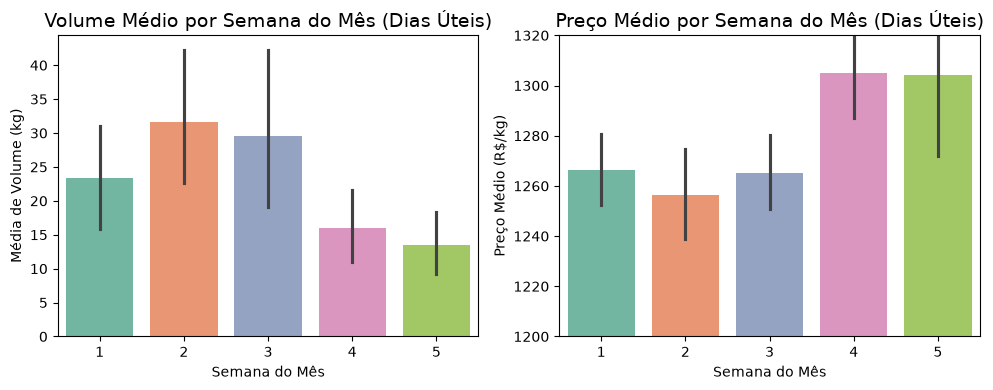

In [17]:
# 2. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Gráfico da Esquerda: Volume
sns.barplot(data=df_uteis, x='Semana do Mês', y='Volume Realizado (kg)', 
            ax=axes[0], palette='Set2', hue='Semana do Mês', legend=False)
axes[0].set_title('Volume Médio por Semana do Mês (Dias Úteis)', fontsize=14)
axes[0].set_ylabel('Média de Volume (kg)')

# Gráfico da Direita: Preço
sns.barplot(data=df_uteis, x='Semana do Mês', y='Preço', 
            ax=axes[1], palette='Set2', hue='Semana do Mês', legend=False)
axes[1].set_title('Preço Médio por Semana do Mês (Dias Úteis)', fontsize=14)
axes[1].set_ylabel('Preço Médio (R$/kg)')
axes[1].set_ylim(1200, 1320)

plt.tight_layout()
plt.show()


In [18]:

# 3. Prova Matemática (P-valor da Semana do Mês)
# Como são 5 semanas no mês, o Python usa a 'Semana 1' como base (const) e testa as outras 4.
dummies_semana = pd.get_dummies(df_uteis['Semana do Mês'], drop_first=True, prefix='Semana', dtype=int)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

X_semana = df_uteis[['ln_Preco']].join([dummies_semana, dummies_dia])
X_semana = sm.add_constant(X_semana)
y = df_uteis['ln_Volume']

modelo_semana = sm.OLS(y, X_semana).fit()

print("=== Relevância da SEMANA DO MÊS ===")
print("Categoria Base (const): Semana 1 e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_semana.summary().tables[1])

=== Relevância da SEMANA DO MÊS ===
Categoria Base (const): Semana 1 e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.1348     15.080      6.972      0.000      74.925     135.344
ln_Preco     -14.2844      2.111     -6.766      0.000     -18.513     -10.055
Semana_2       0.2367      0.162      1.466      0.148      -0.087       0.560
Semana_3       0.2057      0.161      1.280      0.206      -0.116       0.528
Semana_4       0.0351      0.173      0.203      0.840      -0.311       0.381
Semana_5       0.2274      0.222      1.023      0.311      -0.218       0.673
Quinta        -0.0511      0.173     -0.296      0.768      -0.397       0.295
Segunda        0.3138      0.173      1.818      0.074      -0.032       0.660

### Quinzena

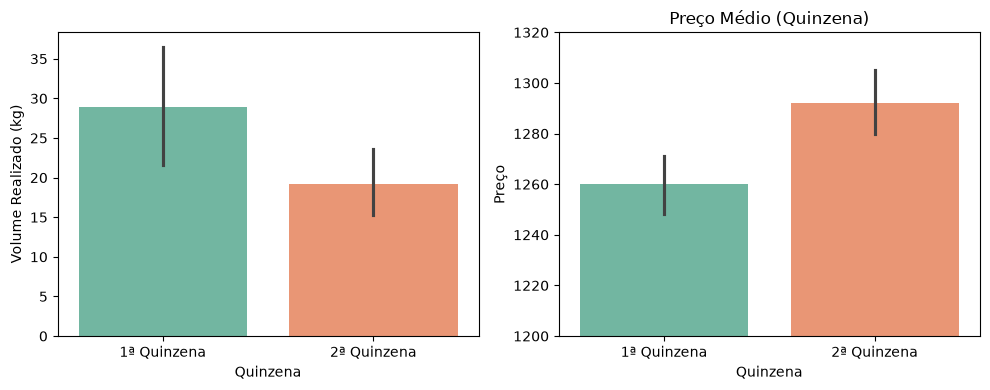

In [19]:
# 1. Gráficos
ordem_quinzena = ['1ª Quinzena', '2ª Quinzena']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=df_uteis, x='Quinzena', y='Volume Realizado (kg)', order=ordem_quinzena, ax=axes[0], palette='Set2',
            hue='Quinzena', legend=False)

sns.barplot(data=df_uteis, x='Quinzena', y='Preço', order=ordem_quinzena, ax=axes[1], palette='Set2',
            hue='Quinzena', legend=False)
axes[1].set_title('Preço Médio (Quinzena)', fontsize=12)
axes[1].set_ylim(1200, 1320)

plt.tight_layout()
plt.show()

In [20]:
# 4. Prova Matemática (Teste Isolado para a Quinzena)
# Transformação Log-Log (Garantindo que as colunas existam)
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# Criando as Dummies da Quinzena (A base 'const' será 1ª Quinzena)
dummies_quinzena = pd.get_dummies(df_uteis['Quinzena'], drop_first=True, dtype=int)
# Criando as Dummies do Dia (A base 'const' será Quarta-feira)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

# Juntando: Preço + Quinzena + Dia da Semana
X_quinzena = df_uteis[['ln_Preco']].join([dummies_quinzena, dummies_dia])
X_quinzena = sm.add_constant(X_quinzena)
y = df_uteis['ln_Volume']

# Ajustando o modelo
modelo_quinzena = sm.OLS(y, X_quinzena).fit()

print("=== Relevância da QUINZENA ===")
print("Categoria Base (const): 1ª Quinzena e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_quinzena.summary().tables[1])

=== Relevância da QUINZENA ===
Categoria Base (const): 1ª Quinzena e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         112.8260     14.197      7.947      0.000      84.418     141.234
ln_Preco      -15.3459      1.989     -7.716      0.000     -19.325     -11.367
2ª Quinzena     0.0582      0.120      0.485      0.629      -0.182       0.298
Quinta         -0.0554      0.173     -0.320      0.750      -0.402       0.291
Segunda         0.3167      0.173      1.831      0.072      -0.029       0.663
Sexta          -1.2882      0.170     -7.582      0.000      -1.628      -0.948
Terça          -0.0353      0.173     -0.204      0.839      -0.382       0.311


### Mês

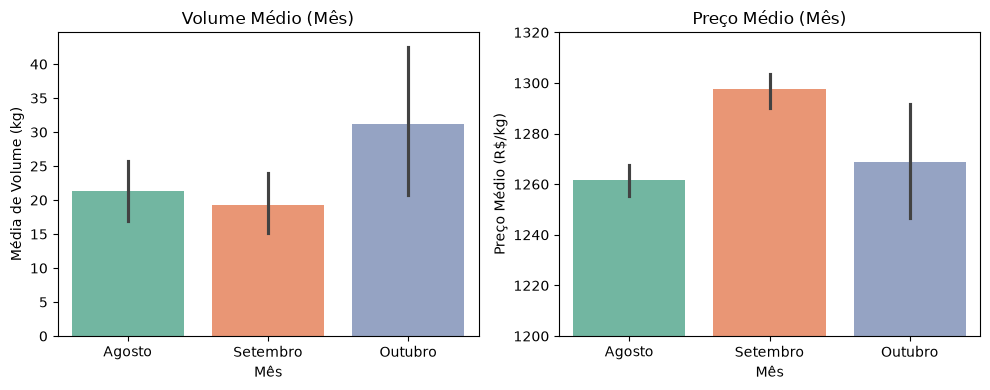

In [21]:
# 1. Configurando a ordem dos meses para o gráfico fazer sentido cronológico
ordem_meses = ['Agosto', 'Setembro', 'Outubro']

# 2. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Gráfico da Esquerda: Volume Médio por Mês
sns.barplot(data=df_uteis, x='Mês', y='Volume Realizado (kg)', 
            order=ordem_meses, ax=axes[0], palette='Set2',
            hue='Mês', legend=False)
axes[0].set_title('Volume Médio (Mês)', fontsize=12)
axes[0].set_ylabel('Média de Volume (kg)')
axes[0].set_xlabel('Mês')

# Gráfico da Direita: Preço Médio por Mês
sns.barplot(data=df_uteis, x='Mês', y='Preço', 
            order=ordem_meses, ax=axes[1], palette='Set2',
            hue='Mês', legend=False)
axes[1].set_title('Preço Médio (Mês)', fontsize=12)
axes[1].set_ylabel('Preço Médio (R$/kg)')
axes[1].set_xlabel('Mês')
axes[1].set_ylim(1200, 1320) # Cortando o eixo Y para evidenciar a diferença de preço

plt.tight_layout()
plt.show()


In [22]:

# 3. Prova Estatística (Teste Isolado para o Mês)
# Garantindo as variáveis logarítmicas
df_uteis['ln_Volume'] = np.log(df_uteis['Volume Realizado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# Criando as Dummies do Mês (A base 'const' será Agosto) e Dia da Semana
dummies_mes = pd.get_dummies(df_uteis['Mês'], drop_first=True, dtype=int)
dummies_dia = pd.get_dummies(df_uteis['Dia da Semana'], drop_first=True, dtype=int)

# Juntando: Preço + Mês + Dia da Semana
X_mes = df_uteis[['ln_Preco']].join([dummies_mes, dummies_dia])
X_mes = sm.add_constant(X_mes)
y = df_uteis['ln_Volume']

# Ajustando o modelo
modelo_mes = sm.OLS(y, X_mes).fit()

print("=== Relevância do MÊS ===")
print("Categoria Base (const): Agosto e Quarta-feira")
print("Regra: Se P>|t| for > 0.05, a variável não tem impacto real.")
print("-" * 65)
print(modelo_mes.summary().tables[1])

=== Relevância do MÊS ===
Categoria Base (const): Agosto e Quarta-feira
Regra: Se P>|t| for > 0.05, a variável não tem impacto real.
-----------------------------------------------------------------
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.6866     13.953      8.363      0.000      88.758     144.616
ln_Preco     -15.8997      1.954     -8.137      0.000     -19.811     -11.988
Outubro        0.1564      0.132      1.183      0.242      -0.108       0.421
Setembro       0.2132      0.144      1.477      0.145      -0.076       0.502
Quinta        -0.0509      0.171     -0.297      0.767      -0.394       0.292
Segunda        0.3139      0.172      1.830      0.072      -0.029       0.657
Sexta         -1.2773      0.168     -7.593      0.000      -1.614      -0.941
Terça         -0.0341      0.171     -0.199      0.843      -0.377       0.309


## Teste Para dias da semana

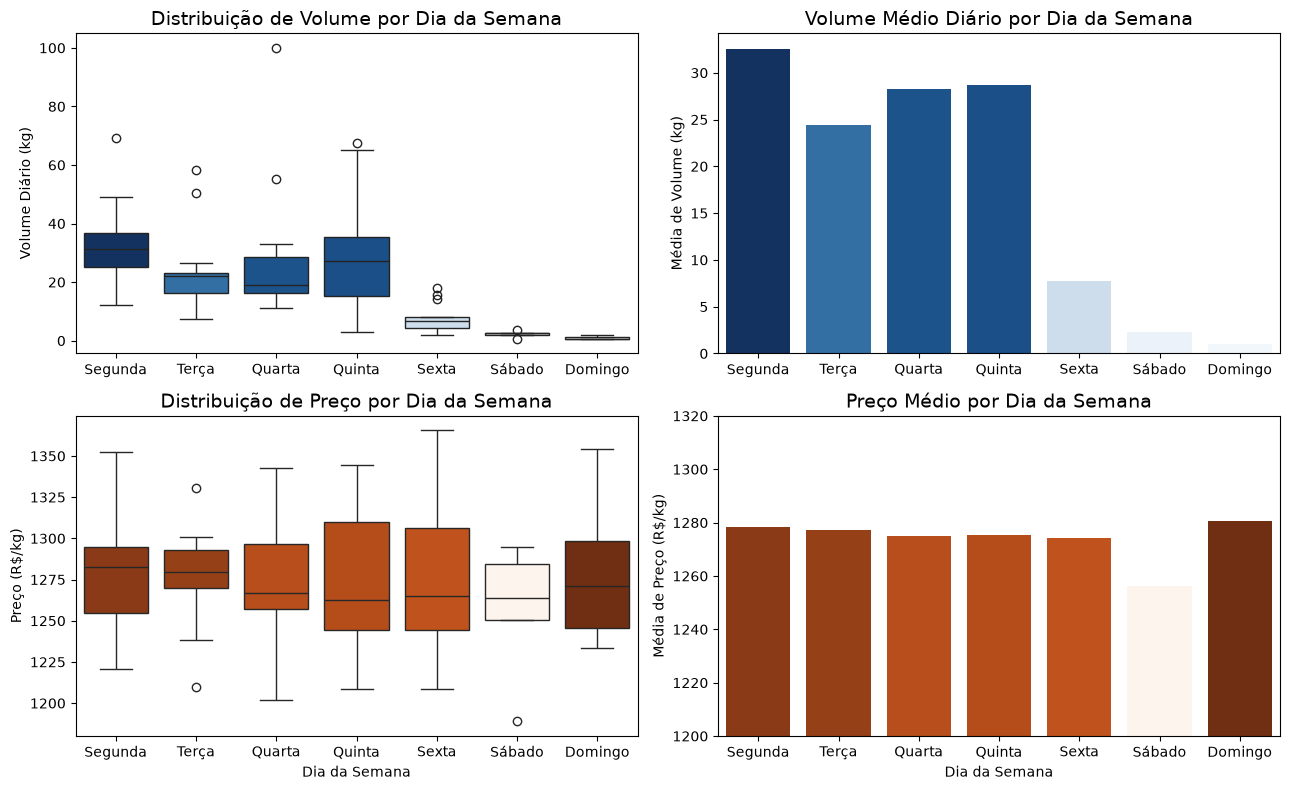

In [23]:
# 1. Ordenando os dias para o eixo X do gráfico fazer sentido
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# 2. Calculando as médias por dia (Volume e Preço)
medias_vol = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].mean()
medias_preco = df_treino.groupby('Dia da Semana')['Preço'].mean()

# 3. Criando normalizadores e dicionários de cores dinâmicas (Estilo Heatmap)
# --- Paleta do Volume (Azul) ---
norm_vol = mcolors.Normalize(vmin=0, vmax=medias_vol.max())
cmap_vol = plt.get_cmap('Blues') 
paleta_vol = {dia: cmap_vol(norm_vol(medias_vol[dia])) for dia in ordem_dias}

# --- Paleta do Preço (Laranja) ---
norm_preco = mcolors.Normalize(vmin=medias_preco.min(), vmax=medias_preco.max())
cmap_preco = plt.get_cmap('Oranges') 
paleta_preco = {dia: cmap_preco(norm_preco(medias_preco[dia])) for dia in ordem_dias}

# 4. Criando a matriz de gráficos (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ==========================================
# LINHA 0 (CIMA): GRÁFICOS DE VOLUME
# ==========================================
# Boxplot Volume
sns.boxplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[0, 0], palette=paleta_vol, hue='Dia da Semana', legend=False)
axes[0, 0].set_title("Distribuição de Volume por Dia da Semana", fontsize=14)
axes[0, 0].set_xlabel("") # Esconde o X label para não poluir
axes[0, 0].set_ylabel("Volume Diário (kg)")

# Barplot Volume
sns.barplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[0, 1], errorbar=None, palette=paleta_vol, hue='Dia da Semana', legend=False)
axes[0, 1].set_title("Volume Médio Diário por Dia da Semana", fontsize=14)
axes[0, 1].set_xlabel("") # Esconde o X label para não poluir
axes[0, 1].set_ylabel("Média de Volume (kg)")


# ==========================================
# LINHA 1 (BAIXO): GRÁFICOS DE PREÇO
# ==========================================
# Boxplot Preço
sns.boxplot(data=df_treino, x='Dia da Semana', y='Preço', 
            order=ordem_dias, ax=axes[1, 0], palette=paleta_preco, hue='Dia da Semana', legend=False)
axes[1, 0].set_title("Distribuição de Preço por Dia da Semana", fontsize=14)
axes[1, 0].set_xlabel("Dia da Semana")
axes[1, 0].set_ylabel("Preço (R$/kg)")

# Barplot Preço
sns.barplot(data=df_treino, x='Dia da Semana', y='Preço', 
            order=ordem_dias, ax=axes[1, 1], errorbar=None, palette=paleta_preco, hue='Dia da Semana', legend=False)
axes[1, 1].set_title("Preço Médio por Dia da Semana", fontsize=14)
axes[1, 1].set_xlabel("Dia da Semana")
axes[1, 1].set_ylabel("Média de Preço (R$/kg)")
axes[1, 1].set_ylim(1200, 1320) # Dá "zoom" na variação

# Ajusta o espaçamento entre os subplots e exibe
plt.tight_layout()
plt.show()

### analise do boxplot e de barras
- segunda é o dia com maior volume médio e maior mediana, boxplot razoavelmente comportado (caixa pequena)
    possivel sensibilidade menor a preços altos
- quarta é o terceior maior volume, mas mediana menor que terça, com um grande outlier em 100 que puxou a media.
    dia complicado para usar somente a media na modelagem
- quinta segue com o segundo volume médio, porem caixa longa , bigodes muito extremos variando de quase 0 até 60
    fica um dia dia muito volatil, talvez mais impactado por fatores externos
- de sexta em diante o volume despenca, distribuicao mais comportada do boxplot
    baixar preço nesse periodo pode ser um erro (cliente nao compra naturalmente)

    
Pensando na Modelagem:Ao desenhar as curvas de elasticidade $Volume = A \cdot \text{Preço}^{-B}$ penso que as evidenciass visuais  indicam que será necessario pelo menos três comportamentos distintos:
- Segunda e Quinta: Dias de alta tração (podem suportar preços marginalmente maiores se o volume já estiver garantido).
- Terça e Quarta: Dias de tração média/estável (onde a sensibilidade ao preço deve ditar o volume).
- Sexta a Domingo: Dias de baixa, indicam que grandes mudanças do preço não trarão maior volume.

### ⚠️ Melhoria 3 — Quantos dias de dado sustentam cada cluster?

Antes de seguir com a hipótese dos 3 clusters (Pico / Regular / Fraco), vale checar
em número quantas observações de treino cada um tem. Poucas observações (ex: menos de
15-20) significam que **um único dia fora do padrão** (chuva, feriado, ação do concorrente)
pode distorcer bastante a conclusão para aquele grupo.

In [24]:
# Contagem de observações de treino por dia da semana e por cluster proposto
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
contagem_dia = df_treino[df_treino['Dia da Semana'].isin(ordem_dias)]['Dia da Semana'].value_counts().reindex(ordem_dias)
print("Observações de treino por dia útil:")
print(contagem_dia)
print()

def agrupar_clusters_check(dia):
    if dia in ['Segunda', 'Quinta']:
        return 'Cluster 1 (Pico)'
    elif dia in ['Terça', 'Quarta']:
        return 'Cluster 2 (Regular)'
    else:
        return 'Cluster 3 (Fraco)'

contagem_cluster = df_treino[df_treino['Dia da Semana'].isin(ordem_dias)]['Dia da Semana'] \
    .apply(agrupar_clusters_check).value_counts()
print("Observações de treino por cluster proposto:")
print(contagem_cluster)
print()
print("Regra prática: com menos de ~20 observações, trate a conclusão daquele cluster com")
print("mais cautela — é o caso do Cluster 3 (Fraco), que hoje tem só os dias de Sexta.")
print("(Mais adiante, no Torneio de Modelos, vamos testar se essa divisão é mesmo a melhor.)")

Observações de treino por dia útil:
Dia da Semana
Segunda    13
Terça      13
Quarta     13
Quinta     13
Sexta      14
Name: count, dtype: int64

Observações de treino por cluster proposto:
Dia da Semana
Cluster 1 (Pico)       26
Cluster 2 (Regular)    26
Cluster 3 (Fraco)      14
Name: count, dtype: int64

Regra prática: com menos de ~20 observações, trate a conclusão daquele cluster com
mais cautela — é o caso do Cluster 3 (Fraco), que hoje tem só os dias de Sexta.
(Mais adiante, no Torneio de Modelos, vamos testar se essa divisão é mesmo a melhor.)


### Heatmap geral

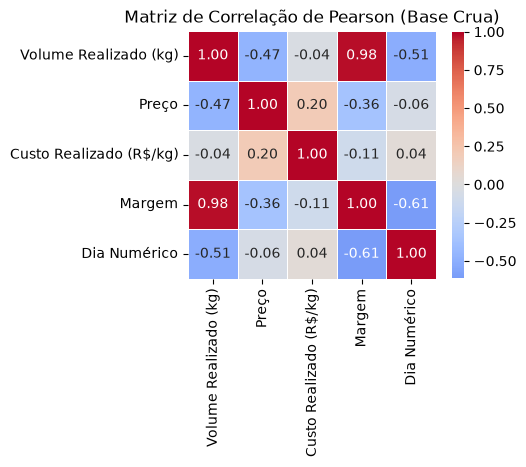

In [25]:
# Criando uma coluna numérica para o dia da semana para usar na correlação
df_treino['Dia Numérico'] = df_treino['Data'].dt.dayofweek

cols_corr = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem', 'Dia Numérico']
matriz_corr = df_treino[cols_corr].corr()

plt.figure(figsize=(4,4))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação de Pearson (Base Crua)", fontsize=12)
plt.show()

### Heatmap da correlação
- volume x preço com -0.47 (preço sobe, demanda cai), mas nao é absoluta
- volume x dia da semana = -0,51 (dia maior, menor volume)
- volume x margem = 0,98 (volume sobe, margem sobe) -> aumentar preço nao faz necessariamente a margem aumentar


In [26]:
# Isolando apenas os dias úteis (Segunda a Sexta) usando o dia numérico

df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])]

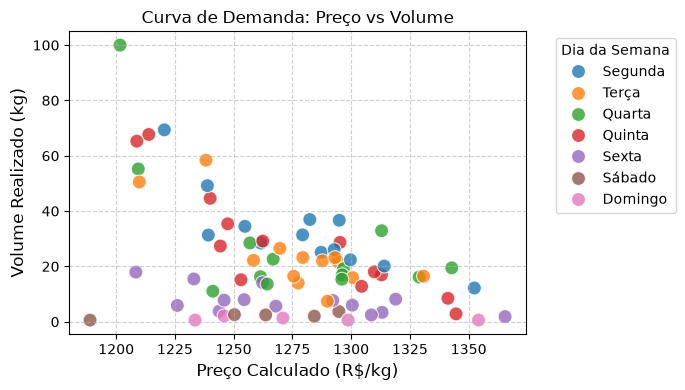

In [27]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_treino, x='Preço', y='Volume Realizado (kg)', 
                hue='Dia da Semana', hue_order=['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo'], 
                palette="tab10", s=100, alpha=0.8)

plt.title("Curva de Demanda: Preço vs Volume", fontsize=12)
plt.xlabel("Preço Calculado (R$/kg)", fontsize=12)
plt.ylabel("Volume Realizado (kg)", fontsize=12)
plt.legend(title="Dia da Semana", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

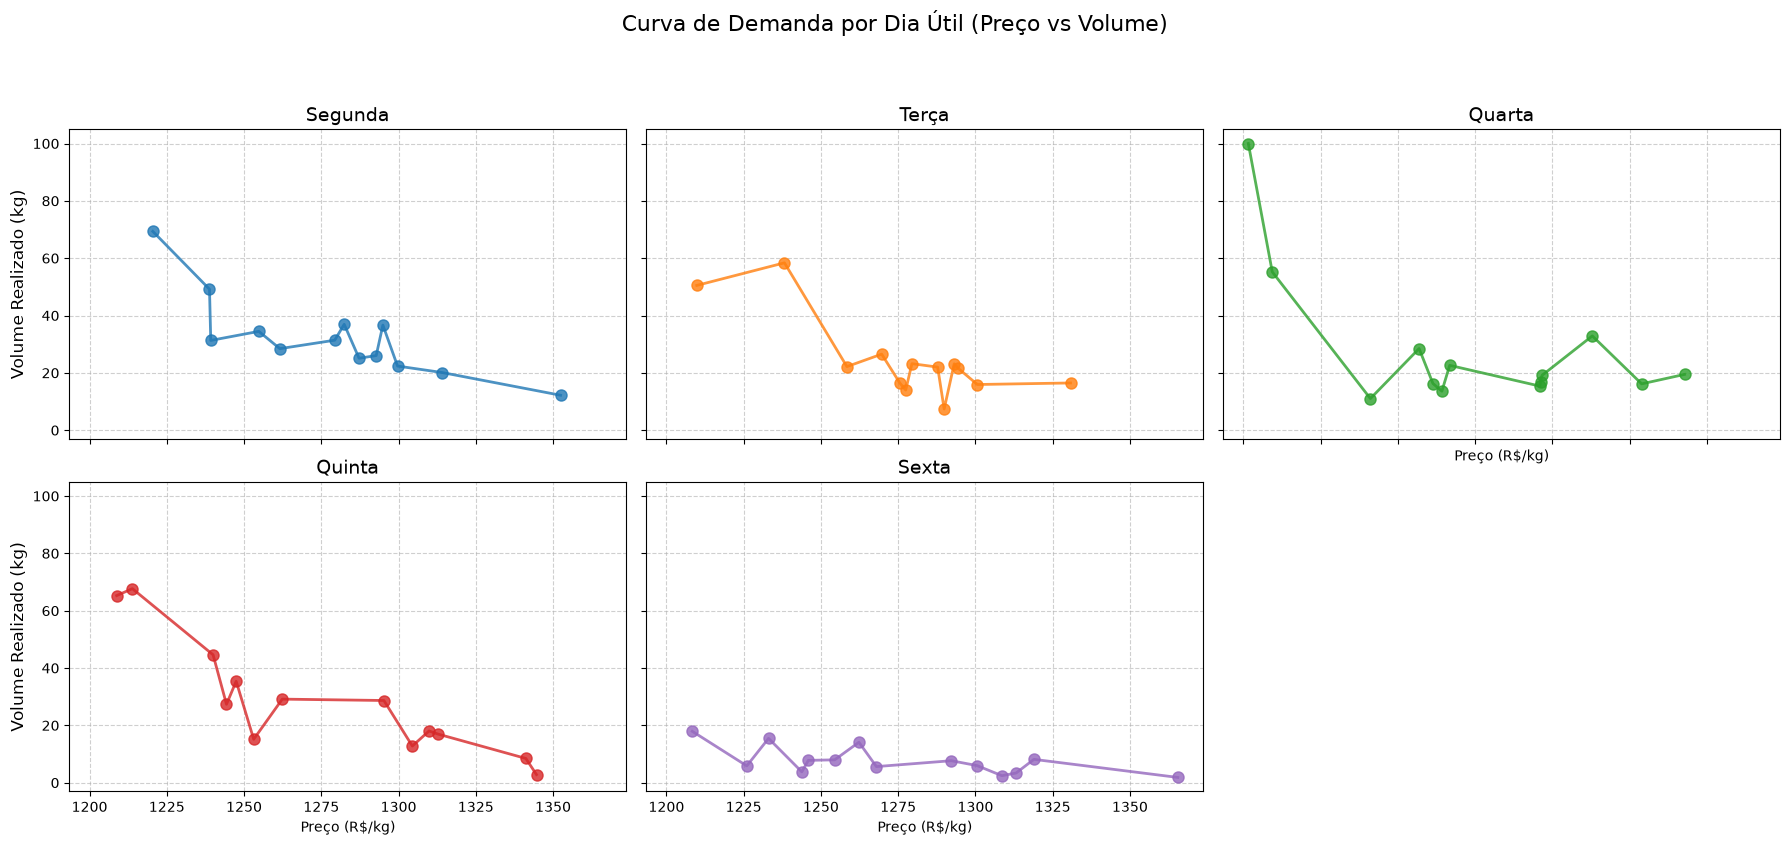

In [28]:
# 2. Ordenar por Preço para a linha fazer sentido da esquerda pra direita
df_uteis = df_uteis.sort_values(by='Preço')

# 3. Configurando a figura em 2 linhas e 3 colunas (altura aumentada para 8)
ordem_uteis = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
cores = sns.color_palette("tab10", 5)

# Achatar a matriz 2x3 para um array unidimensional de 6 posições
axes = axes.flatten() 

# 4. Loop para plotar cada dia
for i, dia in enumerate(ordem_uteis):
    # Filtra o dado do dia específico
    df_dia = df_uteis[df_uteis['Dia da Semana'] == dia]
    
    # Plota a linha conectando os pontos ordenados
    axes[i].plot(df_dia['Preço'], df_dia['Volume Realizado (kg)'], 
                 marker='o', markersize=8, linestyle='-', linewidth=2, 
                 color=cores[i], alpha=0.8)
    
    # Formatação do subplot
    axes[i].set_title(dia, fontsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Adicionando labels aos eixos X (apenas na linha de baixo) e Y (apenas na 1ª coluna)
    if i >= 2:
        axes[i].set_xlabel("Preço (R$/kg)")
    if i % 3 == 0:
        axes[i].set_ylabel("Volume Realizado (kg)", fontsize=12)

# 5. Ocultando o 6º gráfico (vazio) que sobrou na grade
axes[5].set_visible(False)

plt.suptitle("Curva de Demanda por Dia Útil (Preço vs Volume)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### 🔍 Investigando o episódio de 13–24/10 (antes de tratar outliers)

Na Melhoria 2 (linha do tempo), um trecho do meio de outubro chamou atenção: parece
concentrar valores muito extremos de uma vez só. Vale abrir esses dias antes de seguir,
porque um pequeno grupo de pontos assim concentrados pode estar puxando a conclusão final
mais do que deveria — isso se chama **ponto de alavancagem**.

In [29]:
janela_anomalia = df_treino[(df_treino['Data'] >= '2025-10-10') & (df_treino['Data'] <= '2025-10-25')].copy()
cols_num_janela = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)']
janela_anomalia[cols_num_janela] = janela_anomalia[cols_num_janela].round(2)
display(janela_anomalia[['Data', 'Dia da Semana'] + cols_num_janela])

idx_vol = df_treino['Volume Realizado (kg)'].idxmax()
idx_pmin = df_treino['Preço'].idxmin()
idx_pmax = df_treino['Preço'].idxmax()
idx_cmax = df_treino['Custo Realizado (R$/kg)'].idxmax()

print(f"Maior volume de todo o treino: {df_treino.loc[idx_vol, 'Volume Realizado (kg)']:.1f} kg, em {df_treino.loc[idx_vol, 'Data'].date()}")
print(f"Menor preço de todo o treino:  R$ {df_treino.loc[idx_pmin, 'Preço']:.2f}, em {df_treino.loc[idx_pmin, 'Data'].date()}")
print(f"Maior preço de todo o treino:  R$ {df_treino.loc[idx_pmax, 'Preço']:.2f}, em {df_treino.loc[idx_pmax, 'Data'].date()}")
print(f"Maior custo/kg de todo o treino: R$ {df_treino.loc[idx_cmax, 'Custo Realizado (R$/kg)']:.2f}, em {df_treino.loc[idx_cmax, 'Data'].date()}")
print()
print("Repare que TODOS esses extremos caem dentro (ou logo depois) da janela acima.")
print("Tem cara de um episódio só (uma promoção de 4 dias, seguida de uma correção de preço")
print("pra compensar) — não um comportamento normal e repetível do cliente. Vale ter isso em")
print("mente ao interpretar a elasticidade estimada mais adiante: uma fração dela pode vir")
print("só desse episódio específico.")

,Data,Dia da Semana,Volume Realizado (kg),Preço,Custo Realizado (R$/kg)
56,2025-10-10,Sexta,17.94,1208.37,980.21
57,2025-10-11,Sábado,0.59,1188.86,978.17
58,2025-10-13,Segunda,69.35,1220.47,984.91
59,2025-10-14,Terça,50.50,1209.83,985.19
60,2025-10-15,Quarta,100.00,1201.63,985.92
61,2025-10-16,Quinta,65.26,1208.78,984.83
62,2025-10-17,Sexta,7.80,1245.93,984.74
63,2025-10-18,Sábado,2.55,1250.31,985.27
64,2025-10-19,Domingo,0.59,1233.57,978.17
65,2025-10-20,Segunda,31.31,1239.22,1030.34


Maior volume de todo o treino: 100.0 kg, em 2025-10-15
Menor preço de todo o treino:  R$ 1188.86, em 2025-10-11
Maior preço de todo o treino:  R$ 1365.49, em 2025-10-24
Maior custo/kg de todo o treino: R$ 1030.34, em 2025-10-20

Repare que TODOS esses extremos caem dentro (ou logo depois) da janela acima.
Tem cara de um episódio só (uma promoção de 4 dias, seguida de uma correção de preço
pra compensar) — não um comportamento normal e repetível do cliente. Vale ter isso em
mente ao interpretar a elasticidade estimada mais adiante: uma fração dela pode vir
só desse episódio específico.


## Outliers

Duas perguntas diferentes se escondem sob o rótulo "outlier" aqui:

- **Premissa A — outlier como propriedade da variável isolada**: um valor é estranho olhando só
  para a distribuição da própria variável (ex.: Volume muito acima do que aquele dia da semana
  costuma vender), sem olhar o preço praticado naquele dia. É o que o capping por IQR abaixo faz —
  hoje só para Volume; mais abaixo, o mesmo teste é replicado para Preço, pela primeira vez.
- **Premissa B — outlier como propriedade da curva de elasticidade**: um valor é estranho quando o
  Volume observado não bate com o que o modelo Preço→Volume prevê para aquele preço, mesmo que,
  isoladamente, nem o Volume nem o Preço pareçam extremos. Tecnicamente essa é a pergunta que
  realmente importa para a elasticidade — um volume "alto" pode ser perfeitamente normal se o
  preço daquele dia também estava baixo, que é exatamente o comportamento que a curva prevê.

A Premissa A é tratada nesta seção, porque não depende de nenhum modelo já ajustado. A Premissa B
só pode ser testada depois que existe um modelo — ela aparece formalmente na seção "Duas Premissas
de Outlier, Lado a Lado", logo após o Torneio de Modelos, onde as duas são comparadas ponto a
ponto.


In [30]:
# 1. Função para calcular o limite do Boxplot e aplicar o Capping
def trata_outliers_por_grupo(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    # Substitui os valores acima do limite pelo próprio limite
    return np.clip(serie, a_min=None, a_max=limite_superior)

# 2. Aplicando a função dia a dia
df_treino['Volume Tratado (kg)'] = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].transform(trata_outliers_por_grupo)

# 3. Imprimindo os limites calculados para cada dia 
limites_calculados = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].apply(
    lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25))
)
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
print("=== Tetos Matemáticos Calculados (kg) ===")
print(limites_calculados.reindex(ordem_dias).round(2))
print("-" * 40)

# 4. Comparativo de Médias: Suja vs Limpa
comparativo_dias = df_treino.groupby('Dia da Semana')[['Volume Realizado (kg)', 'Volume Tratado (kg)']].mean().reindex(ordem_dias)
comparativo_dias['Queda após limpeza (%)'] = ((comparativo_dias['Volume Tratado (kg)'] / comparativo_dias['Volume Realizado (kg)']) - 1) * 100

print("\n=== Impacto do Tratamento nas Médias ===")
display(comparativo_dias.round(2))

=== Tetos Matemáticos Calculados (kg) ===
Dia da Semana
Segunda    54.02
Terça      33.37
Quarta     46.94
Quinta     65.75
Sexta      13.89
Sábado      3.37
Domingo     2.46
Name: Volume Realizado (kg), dtype: float64
----------------------------------------

=== Impacto do Tratamento nas Médias ===


,Volume Realizado (kg),Volume Tratado (kg),Queda após limpeza (%)
Dia da Semana,,,
Segunda,32.58,31.40,-3.62
Terça,24.45,21.21,-13.26
Quarta,28.25,23.53,-16.70
Quinta,28.64,28.49,-0.52
Sexta,7.72,7.30,-5.41
Sábado,2.26,2.19,-2.82
Domingo,1.04,1.04,0.00


### Aplicando a mesma pergunta ao Preço (e comparando os dois)

O capping usado na modelagem acima só corta o **teto** do Volume (decisão consciente, para não
alterar a variável usada no modelo já validado). Antes de seguir, vale aplicar a mesma lógica de
IQR — agora dos dois lados (piso e teto) — em Volume e Preço isoladamente, só para diagnóstico, e
comparar quantos dias cada variável flagra por si só.


In [31]:
# Premissa A, versão de dois lados (piso e teto), só para diagnóstico — não altera as
# variáveis usadas na modelagem (Volume Tratado / Preço permanecem como estavam).
def flagra_outlier_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    piso, teto = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (serie < piso) | (serie > teto)

flag_volume = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].transform(flagra_outlier_iqr)
flag_preco = df_treino.groupby('Dia da Semana')['Preço'].transform(flagra_outlier_iqr)

print("=== Premissa A: outlier por IQR (piso e teto), calculado dentro de cada dia da semana ===")
print(f"Volume: {int(flag_volume.sum())} dia(s) flagrado(s)")
print(f"Preço:  {int(flag_preco.sum())} dia(s) flagrado(s)")
print()
print("Nota: o capping usado na modelagem (célula anterior) só corta o TETO do Volume. Se o mesmo")
print("critério de só-teto fosse usado para o Preço, o dia de preço MÍNIMO (a provável promoção)")
print("não seria flagrado, porque ele é um piso, não um teto — um indício de que a Premissa A, da")
print("forma mais simples de aplicar, tende a deixar passar exatamente o tipo de anomalia mais")
print("relevante neste caso.")
print()
cols_flag = ['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)']
dias_flagrados_A = df_treino.loc[flag_volume | flag_preco, cols_flag]
print(f"Dias flagrados pela Premissa A (Volume e/ou Preço isolados), N={len(dias_flagrados_A)}:")
display(dias_flagrados_A)


=== Premissa A: outlier por IQR (piso e teto), calculado dentro de cada dia da semana ===
Volume: 11 dia(s) flagrado(s)
Preço:  3 dia(s) flagrado(s)

Nota: o capping usado na modelagem (célula anterior) só corta o TETO do Volume. Se o mesmo
critério de só-teto fosse usado para o Preço, o dia de preço MÍNIMO (a provável promoção)
não seria flagrado, porque ele é um piso, não um teto — um indício de que a Premissa A, da
forma mais simples de aplicar, tende a deixar passar exatamente o tipo de anomalia mais
relevante neste caso.

Dias flagrados pela Premissa A (Volume e/ou Preço isolados), N=12:


,Data,Dia da Semana,Preço,Volume Realizado (kg)
16,2025-08-22,Sexta,1262.293498,14.113320
21,2025-08-29,Sexta,1233.052978,15.458500
22,2025-08-30,Sábado,1294.787921,3.683726
53,2025-10-07,Terça,1238.197969,58.386545
54,2025-10-08,Quarta,1209.383360,55.223334
55,2025-10-09,Quinta,1213.857762,67.683350
56,2025-10-10,Sexta,1208.368390,17.936105
57,2025-10-11,Sábado,1188.863746,0.588008
58,2025-10-13,Segunda,1220.469065,69.353642
59,2025-10-14,Terça,1209.831514,50.503658


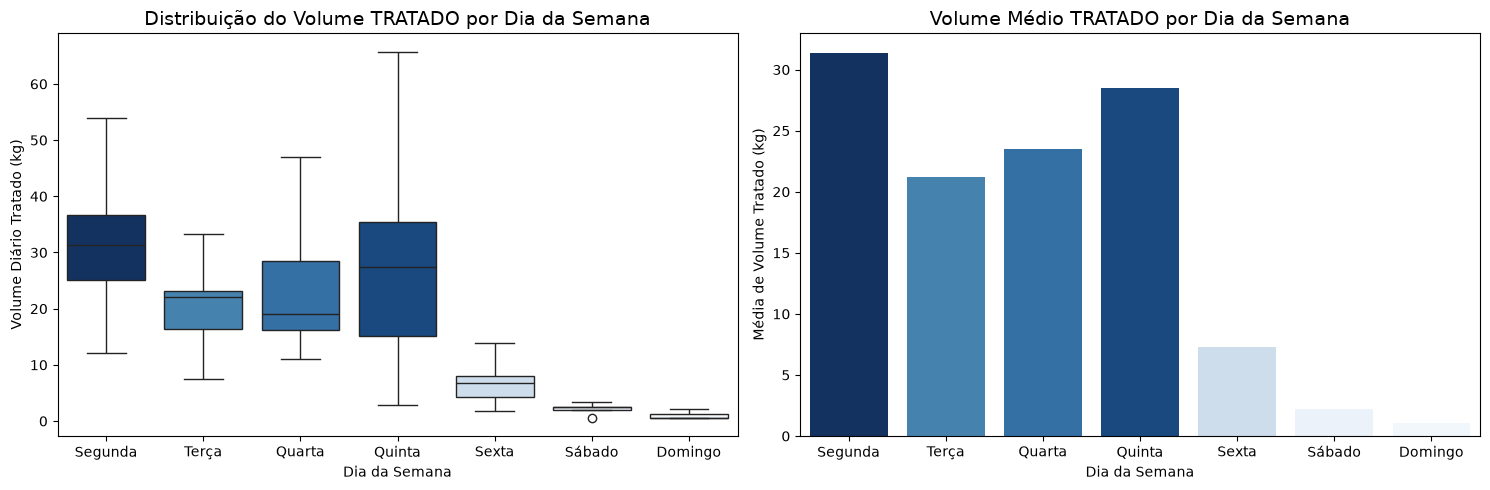

In [32]:
# 1. Definindo apenas os dias úteis na ordem correta
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# 2. Calculando a nova média tratada para o mapa de cores
medias_tratadas = df_treino.groupby('Dia da Semana')['Volume Tratado (kg)'].mean()

# 3. Criando o dicionário de cores dinâmicas (Tons de Azul)
norm_tratado = mcolors.Normalize(vmin=0, vmax=medias_tratadas.max())
cmap_tratado = plt.get_cmap('Blues') 
paleta_tratada = {dia: cmap_tratado(norm_tratado(medias_tratadas[dia])) for dia in ordem_dias}

# 4. Criando os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Boxplot: Distribuição Tratada ---
sns.boxplot(data=df_treino, x='Dia da Semana', y='Volume Tratado (kg)', 
            order=ordem_dias, ax=axes[0], palette=paleta_tratada, hue='Dia da Semana', legend=False)
axes[0].set_title("Distribuição do Volume TRATADO por Dia da Semana", fontsize=14)
axes[0].set_xlabel("Dia da Semana")
axes[0].set_ylabel("Volume Diário Tratado (kg)")

# --- Barplot: Média Tratada ---
sns.barplot(data=df_treino, x='Dia da Semana', y='Volume Tratado (kg)', 
            order=ordem_dias, ax=axes[1], errorbar=None, palette=paleta_tratada, hue='Dia da Semana', legend=False)
axes[1].set_title("Volume Médio TRATADO por Dia da Semana", fontsize=14)
axes[1].set_xlabel("Dia da Semana")
axes[1].set_ylabel("Média de Volume Tratado (kg)")

plt.tight_layout()
plt.show()

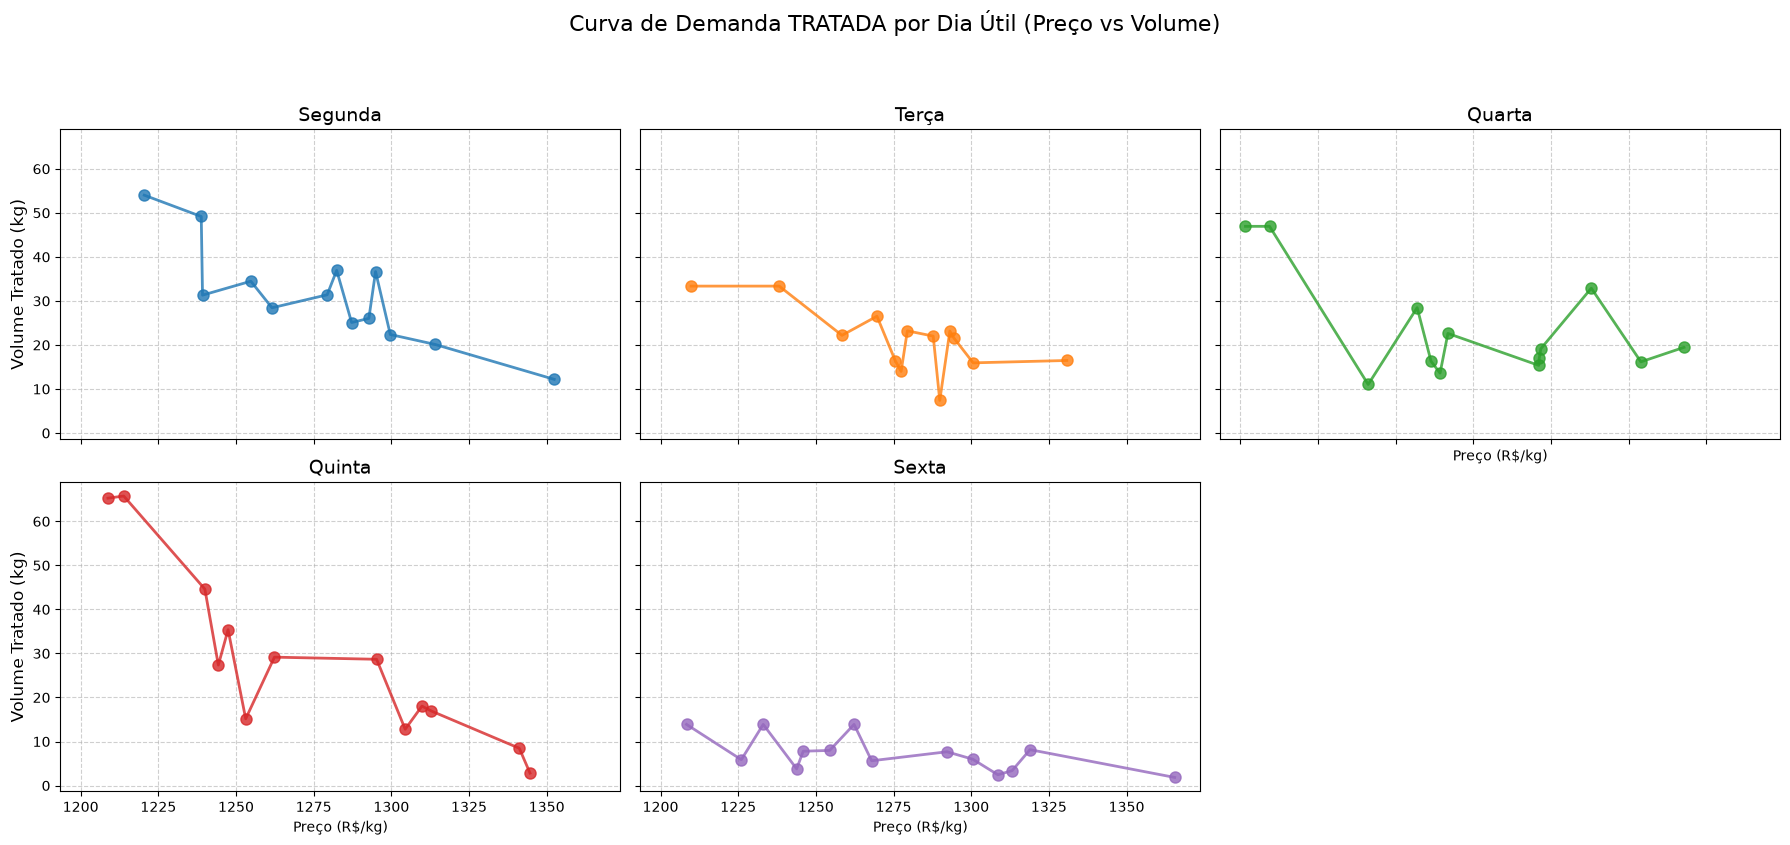

In [33]:
# 1. Isolando os dias úteis
df_uteis_tratado = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])].copy()

# 2. Ordenar por Preço para a linha fazer sentido da esquerda pra direita
df_uteis_tratado = df_uteis_tratado.sort_values(by='Preço')

# 3. Configurando a figura em 2 linhas e 3 colunas
ordem_uteis = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
cores = sns.color_palette("tab10", 5)

# Achatar a matriz 2x3 para um array unidimensional de 6 posições
axes = axes.flatten() 

# 4. Loop para plotar cada dia
for i, dia in enumerate(ordem_uteis):
    # Filtra o dado do dia específico
    df_dia = df_uteis_tratado[df_uteis_tratado['Dia da Semana'] == dia]
    
    # Plota a linha conectando os pontos ordenados (AGORA USANDO O VOLUME TRATADO)
    axes[i].plot(df_dia['Preço'], df_dia['Volume Tratado (kg)'], 
                 marker='o', markersize=8, linestyle='-', linewidth=2, 
                 color=cores[i], alpha=0.8)
    
    # Formatação do subplot
    axes[i].set_title(dia, fontsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Adicionando labels aos eixos X e Y nos lugares corretos
    if i >= 2:
        axes[i].set_xlabel("Preço (R$/kg)")
    if i % 3 == 0:
        axes[i].set_ylabel("Volume Tratado (kg)", fontsize=12)

# 5. Ocultando o 6º gráfico (vazio) que sobrou na grade
axes[5].set_visible(False)

plt.suptitle("Curva de Demanda TRATADA por Dia Útil (Preço vs Volume)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

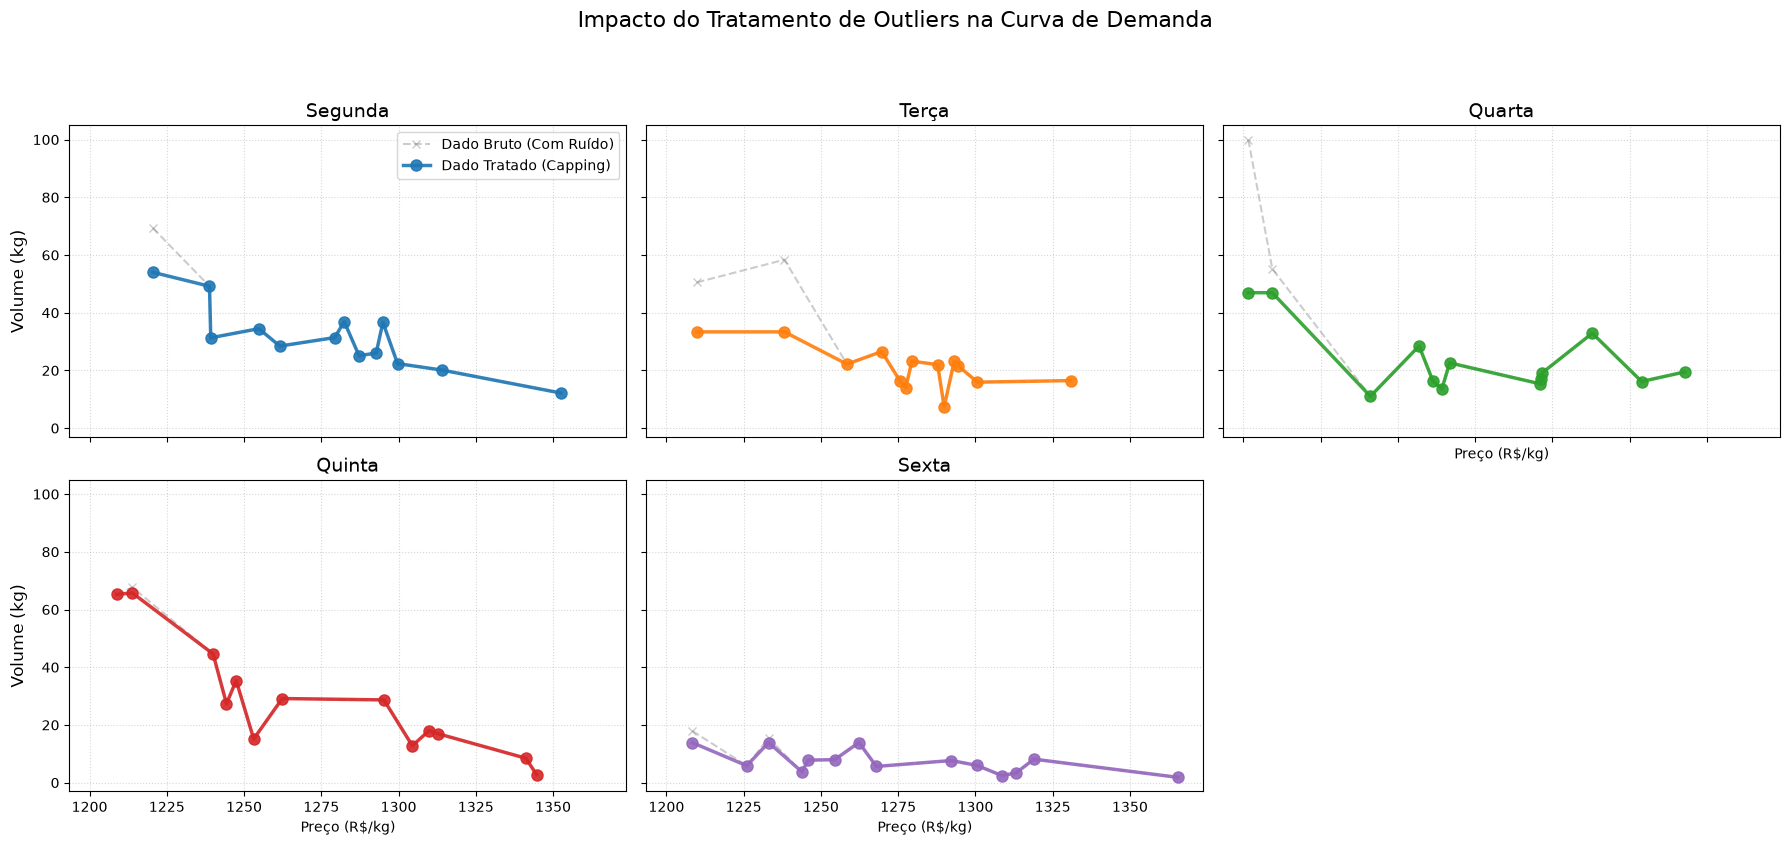

In [34]:
# 1. Isolando e ordenando os dados
df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])].copy()
df_uteis = df_uteis.sort_values(by='Preço')

# 2. Configurando a figura em 2 linhas e 3 colunas
ordem_uteis = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True, sharex=True)
cores = sns.color_palette("tab10", 5)
axes = axes.flatten() 

# 3. Loop para plotar cada dia (Dupla sobreposição)
for i, dia in enumerate(ordem_uteis):
    df_dia = df_uteis[df_uteis['Dia da Semana'] == dia]
    
    # Camada 1: Fundo (Dado Bruto / Com Outliers)
    axes[i].plot(df_dia['Preço'], df_dia['Volume Realizado (kg)'], 
                 marker='x', markersize=6, linestyle='--', linewidth=1.5, 
                 color='grey', alpha=0.4, label='Dado Bruto (Com Ruído)')
                 
    # Camada 2: Frente (Dado Tratado / Limpo)
    axes[i].plot(df_dia['Preço'], df_dia['Volume Tratado (kg)'], 
                 marker='o', markersize=8, linestyle='-', linewidth=2.5, 
                 color=cores[i], alpha=0.9, label='Dado Tratado (Capping)')
    
    # Formatação do subplot
    axes[i].set_title(dia, fontsize=14)
    axes[i].grid(True, linestyle=':', alpha=0.5)
    
    # Labels
    if i >= 2:
        axes[i].set_xlabel("Preço (R$/kg)")
    if i % 3 == 0:
        axes[i].set_ylabel("Volume (kg)", fontsize=12)
        
    # Adicionando a legenda apenas no primeiro gráfico para não poluir
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=10)

# 4. Ocultando o 6º gráfico (vazio)
axes[5].set_visible(False)

plt.suptitle("Impacto do Tratamento de Outliers na Curva de Demanda", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Hipótese Inicial (pré-Torneio): cluster definido pelo boxplot

O modelo abaixo usa o agrupamento de 3 clusters lido visualmente no boxplot da seção anterior
(Segunda+Quinta = Pico, Terça+Quarta = Regular, Sexta = Fraco), sobre o Volume já tratado
(Premissa A). Ele **não é o modelo final** — é o ponto de partida que será desafiado formalmente
pelo Torneio de Modelos mais abaixo, junto com uma hipótese alternativa de agrupamento.


In [35]:
# 1. Isolando os dias úteis para o modelo B2B
df_uteis = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()

# 2. Transformação Log-Log usando o Dado Limpo!
df_uteis['ln_Volume_Tratado'] = np.log(df_uteis['Volume Tratado (kg)'])
df_uteis['ln_Preco'] = np.log(df_uteis['Preço'])

# 3. Mapeando os Clusters definidos no EDA
def agrupar_clusters(dia):
    if dia in ['Segunda', 'Quinta']:
        return 'Cluster 1 (Pico)'
    elif dia in ['Terça', 'Quarta']:
        return 'Cluster 2 (Regular)'
    else:
        return 'Cluster 3 (Fraco)' # Sexta-feira

df_uteis['Cluster'] = df_uteis['Dia da Semana'].apply(agrupar_clusters)

# 4. Criando Dummies SEM exclusão automática
dummies_cluster = pd.get_dummies(df_uteis['Cluster'], dtype=int)

# 5. Excluindo MANUALMENTE o Cluster 2 para forçá-lo a ser a Categoria Base (const)
dummies_cluster = dummies_cluster.drop('Cluster 2 (Regular)', axis=1)

# 6. Montando a Regressão
X_final = df_uteis[['ln_Preco']].join(dummies_cluster)
X_final = sm.add_constant(X_final)
y_final = df_uteis['ln_Volume_Tratado']

modelo_final = sm.OLS(y_final, X_final).fit()

print("=== MODELO INICIAL (HIPÓTESE PRÉ-TORNEIO) ===")
print("Variável Alvo: ln_Volume_Tratado")
print("Categoria Base (const): Cluster 2 (Regular - Ter/Qua)")
print("-" * 65)
print(modelo_final.summary().tables[1])

=== MODELO INICIAL (HIPÓTESE PRÉ-TORNEIO) ===
Variável Alvo: ln_Volume_Tratado
Categoria Base (const): Cluster 2 (Regular - Ter/Qua)
-----------------------------------------------------------------
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                94.5427     12.429      7.607      0.000      69.698     119.387
ln_Preco            -12.7978      1.738     -7.364      0.000     -16.272      -9.324
Cluster 1 (Pico)      0.2094      0.118      1.778      0.080      -0.026       0.445
Cluster 3 (Fraco)    -1.2208      0.141     -8.669      0.000      -1.502      -0.939


In [36]:
# 1. Copiando as variáveis do modelo anterior
X_interacao = X_final.copy()

# 2. Criando os "Multiplicadores de Elasticidade" (Interações)
X_interacao['ln_Preco_x_Cluster_1'] = X_interacao['ln_Preco'] * X_interacao['Cluster 1 (Pico)']
X_interacao['ln_Preco_x_Cluster_3'] = X_interacao['ln_Preco'] * X_interacao['Cluster 3 (Fraco)']

# 3. Rodando o novo modelo com Interações
modelo_multipla_elast = sm.OLS(y_final, X_interacao).fit()

print("=== TESTE DE ELASTICIDADE MÚLTIPLA ===")
print("Se o P>|t| das interações for > 0.05, a elasticidade é a mesma para todos os dias.")
print("-" * 65)
print(modelo_multipla_elast.summary().tables[1])

=== TESTE DE ELASTICIDADE MÚLTIPLA ===
Se o P>|t| das interações for > 0.05, a elasticidade é a mesma para todos os dias.
-----------------------------------------------------------------
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   55.4987     20.549      2.701      0.009      14.395      96.603
ln_Preco                -7.3381      2.873     -2.554      0.013     -13.086      -1.590
Cluster 1 (Pico)        73.2167     27.779      2.636      0.011      17.650     128.784
Cluster 3 (Fraco)       35.1286     31.478      1.116      0.269     -27.837      98.095
ln_Preco_x_Cluster_1   -10.2088      3.884     -2.628      0.011     -17.979      -2.439
ln_Preco_x_Cluster_3    -5.0829      4.402     -1.155      0.253     -13.889       3.723


In [37]:
# 1. Removendo a interação que falhou no teste de P-valor (Sexta-feira)
X_reduzido = X_interacao.drop(columns=['ln_Preco_x_Cluster_3'])

# 2. Rodando o Modelo Enxuto
modelo_campeao = sm.OLS(y_final, X_reduzido).fit()

print("=== MODELO SEM A INTERAÇAO DE SEXTA-FEIRA ===")
print("Todas as variáveis devem ter P>|t| < 0.05")
print("-" * 65)
print(modelo_campeao.summary().tables[1])

=== MODELO SEM A INTERAÇAO DE SEXTA-FEIRA ===
Todas as variáveis devem ter P>|t| < 0.05
-----------------------------------------------------------------
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   70.9847     15.610      4.547      0.000      39.770     102.200
ln_Preco                -9.5036      2.183     -4.354      0.000     -13.869      -5.139
Cluster 1 (Pico)        57.7307     24.393      2.367      0.021       8.954     106.508
Cluster 3 (Fraco)       -1.2156      0.136     -8.942      0.000      -1.487      -0.944
ln_Preco_x_Cluster_1    -8.0433      3.411     -2.358      0.022     -14.864      -1.223


## 🏆 Torneio de Modelos: comparando candidatos com critério objetivo

Em vez de seguir direto com o modelo acima (definido a partir do boxplot, "no olho"),
vamos testar formalmente vários candidatos — incluindo a proposta original, uma proposta
alternativa de agrupamento, e versões mais simples/mais complexas — usando 3
critérios **decididos antes de olhar o resultado**:

1. **MAPE fora da amostra** (o mais importante — é o que decide se a ferramenta funciona de verdade)
2. **BIC** (parecido com AIC, mas pune mais forte modelos com muitos parâmetros — apropriado
   quando temos poucos dados, que é o nosso caso)
3. **Quantos parâmetros realmente se sustentam estatisticamente** (p < 0,05)

R² sozinho não decide nada aqui — ele quase sempre sobe quando se adiciona mais variáveis,
mesmo sem gerar generalização melhor.

In [38]:
def preparar_candidato(cluster_func, com_interacao):
    m = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
    m['ln_Volume'] = np.log(m['Volume Tratado (kg)'])
    m['ln_Preco'] = np.log(m['Preço'])
    if cluster_func is not None:
        m['Cluster'] = m['Dia da Semana'].apply(cluster_func)
        dumm = pd.get_dummies(m['Cluster'], dtype=int)
        base = dumm.sum().idxmax()  # usa o grupo mais numeroso como categoria de referência
        dumm = dumm.drop(columns=[base])
        m = pd.concat([m, dumm], axis=1)
        cluster_cols = list(dumm.columns)
    else:
        cluster_cols = []
    inter_cols = []
    if com_interacao:
        for c in cluster_cols:
            col = f'ln_Preco_x_{c}'
            m[col] = m['ln_Preco'] * m[c]
            inter_cols.append(col)
    cols = ['ln_Preco'] + cluster_cols + inter_cols
    return m, cols


def avaliar_candidato(nome, cluster_func, com_interacao):
    m, cols = preparar_candidato(cluster_func, com_interacao)
    X = sm.add_constant(m[cols])
    modelo = sm.OLS(m['ln_Volume'], X).fit()

    # validação fora da amostra (período de teste, Nov/2025)
    t = df_teste_raw[~df_teste_raw['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
    t['ln_Preco'] = np.log(t['Preço'])
    if cluster_func is not None:
        t['Cluster'] = t['Dia da Semana'].apply(cluster_func)
        base_cols = [c for c in cols if (not c.startswith('ln_Preco_x_')) and c != 'ln_Preco']
        for c in base_cols:
            t[c] = (t['Cluster'] == c).astype(int)
        for c in [c for c in cols if c.startswith('ln_Preco_x_')]:
            base_col = c.replace('ln_Preco_x_', '')
            t[c] = t['ln_Preco'] * t[base_col]
    Xt = sm.add_constant(t[cols], has_constant='add')
    Xt = Xt[modelo.params.index]
    pred = np.exp(modelo.predict(Xt))
    mape = (abs(t['Volume Realizado (kg)'] - pred) / t['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())

    return modelo, dict(Modelo=nome, R2=round(modelo.rsquared, 3), AIC=round(modelo.aic, 1),
                         BIC=round(modelo.bic, 1), MAPE_teste=round(mape, 1),
                         n_parametros=len(modelo.params), n_significativos=n_sig)


def cluster_oficial(d):
    if d in ['Segunda', 'Quinta']: return 'Pico'
    if d in ['Terça', 'Quarta']: return 'Regular'
    return 'Fraco'

def cluster_final(d):
    """Agrupamento alternativo (Segunda isolada; Terça+Quarta+Quinta juntas) — hipótese a
    ser testada formalmente no torneio."""
    if d == 'Segunda': return 'Pico'
    if d in ['Terça', 'Quarta', 'Quinta']: return 'TerQuaQui'
    return 'Fraco'

candidatos = [
    ('A: Dia a dia (aditivo, sem interação)', lambda d: d, False),
    ('B: Dia a dia (com interação, 1 elasticidade por dia)', lambda d: d, True),
    ('C: Cluster oficial Seg+Qui/Ter+Qua/Sex (sem interação)', cluster_oficial, False),
    ('D: Cluster oficial (com interação) — modelo original', cluster_oficial, True),
    ('E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (sem interação)', cluster_final, False),
    ('F: Só preço, sem diferenciar dia nenhum', None, False),
]

modelos_ajustados = {}
linhas = []
for nome, cf, inter in candidatos:
    modelo, linha = avaliar_candidato(nome, cf, inter)
    modelos_ajustados[nome] = modelo
    linhas.append(linha)

tabela_torneio = pd.DataFrame(linhas)
display(tabela_torneio)

,Modelo,R2,AIC,BIC,MAPE_teste,n_parametros,n_significativos
0,"A: Dia a dia (aditivo, sem interação)",0.741,77.4,90.5,55.7,6,5
1,"B: Dia a dia (com interação, 1 elasticidade po...",0.784,73.3,95.2,57.7,10,1
2,C: Cluster oficial Seg+Qui/Ter+Qua/Sex (sem in...,0.722,78.1,86.9,56.4,4,2
3,D: Cluster oficial (com interação) — modelo or...,0.751,74.9,88.1,60.3,6,3
4,E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (se...,0.741,73.5,82.3,56.5,4,3
5,"F: Só preço, sem diferenciar dia nenhum",0.226,141.7,146.1,125.1,2,1


**Como ler:** o modelo D (o que já estava no notebook) tem o *pior* MAPE fora da amostra
entre os candidatos sérios — adicionar a interação (elasticidade diferente por cluster)
piorou a generalização. O modelo B (uma elasticidade por dia individual) tem o maior R²,
mas isso é overfitting clássico: BIC ruim e quase nenhum parâmetro significativo. O modelo
E (agrupamento alternativo, sem interação) empata ou vence em quase todos os critérios ao mesmo
tempo — é o escolhido daqui pra frente.

In [39]:
modelo_vencedor = modelos_ajustados['E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (sem interação)']

print('=== MODELO VENCEDOR DO TORNEIO ===')
print(modelo_vencedor.summary().tables[1])


=== MODELO VENCEDOR DO TORNEIO ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.2911     12.003      7.939      0.000      71.297     119.285
ln_Preco     -12.9008      1.679     -7.686      0.000     -16.256      -9.545
Fraco         -1.2334      0.128     -9.652      0.000      -1.489      -0.978
Pico           0.3692      0.131      2.810      0.007       0.107       0.632


## 🔎 Defesa do Agrupamento Vencedor: o trio Terça/Quarta/Quinta é mesmo parecido?

O modelo vencedor do Torneio junta Terça, Quarta e Quinta num único grupo ("TerQuaQui"). As curvas
ajustadas **dia a dia** (uma regressão isolada por dia, poucos pontos cada) pareciam mostrar Quarta
e Quinta bem separadas logo no início da faixa de preço. Antes de aceitar isso como um padrão real,
o teste certo é isolar só o trio (mais poder estatístico do que testar todos os dias de uma vez) e
checar se `is_Quarta` e `is_Quinta` (vs. Terça, controlando por preço) são estatisticamente
diferentes de zero — e olhar os resíduos do próprio modelo vencedor, separados por dia.


In [40]:
# Teste isolado no trio Terça/Quarta/Quinta, controlando por preço
trio = df_treino[df_treino['Dia da Semana'].isin(['Terça', 'Quarta', 'Quinta'])].copy()
trio['ln_Volume'] = np.log(trio['Volume Tratado (kg)'])
trio['ln_Preco'] = np.log(trio['Preço'])
trio['is_Quarta'] = (trio['Dia da Semana'] == 'Quarta').astype(int)
trio['is_Quinta'] = (trio['Dia da Semana'] == 'Quinta').astype(int)

X_trio = sm.add_constant(trio[['ln_Preco', 'is_Quarta', 'is_Quinta']])
modelo_trio = sm.OLS(trio['ln_Volume'], X_trio).fit()
print("=== Teste isolado no trio (categoria base: Terça) ===")
print(modelo_trio.summary().tables[1])

# Resíduos do modelo vencedor, separados por dia (dentro do próprio trio)
idx_vencedor = modelo_vencedor.model.data.row_labels
base_vencedor = df_treino.loc[idx_vencedor, ['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)']].reset_index(drop=True)
resid_vencedor = pd.Series(modelo_vencedor.resid.values, name='resid')
resid_por_dia = pd.concat([base_vencedor[['Dia da Semana']], resid_vencedor], axis=1)

print()
print("=== Resíduos do modelo vencedor, por dia (trio) ===")
print(resid_por_dia[resid_por_dia['Dia da Semana'].isin(['Terça', 'Quarta', 'Quinta'])]
      .groupby('Dia da Semana')['resid'].agg(['mean', 'std']).round(3))


=== Teste isolado no trio (categoria base: Terça) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.7853     17.155      5.700      0.000      62.958     132.612
ln_Preco     -13.2540      2.399     -5.526      0.000     -18.123      -8.385
is_Quarta      0.0394      0.177      0.223      0.825      -0.320       0.399
is_Quinta      0.0567      0.177      0.320      0.751      -0.303       0.416

=== Resíduos do modelo vencedor, por dia (trio) ===
                mean    std
Dia da Semana              
Quarta         0.008  0.465
Quinta         0.025  0.515
Terça         -0.033  0.337


**Como ler o resultado:** `is_Quarta` (p = 0,825) e `is_Quinta` (p = 0,751) não são
estatisticamente diferentes de Terça, e a diferença de resíduo médio entre os três dias (0,008 a
0,033) é pequena frente ao desvio-padrão de cada um (0,34 a 0,52) — a variação **dentro** de cada
dia é bem maior que a diferença **entre** eles. O gap visto nas curvas ajustadas dia a dia reflete a
instabilidade de ajustar poucos pontos isoladamente (o mesmo problema do candidato B do Torneio),
não uma diferença estrutural real — o que sustenta manter os três juntos no modelo vencedor.


## 🩺 Duas Premissas de Outlier, Lado a Lado

A seção "Outliers" (acima) tratou a Premissa A: Volume e Preço como variáveis isoladas, via IQR por
dia da semana. Agora que existe um modelo ajustado, dá para testar a Premissa B: um ponto é outlier
quando o Volume observado não bate com o que a própria curva de elasticidade prevê para aquele
preço — via resíduos estudentizados e distância de Cook.

**Cuidado metodológico:** esse diagnóstico precisa ser calculado sobre o Volume **bruto**, não
sobre o `Volume Tratado` (que já sofreu o capping da Premissa A). Usar o dado já tratado
contaminaria o teste — os pontos extremos já teriam sido suavizados antes mesmo de procurar por
eles, e a Premissa B pareceria "não encontrar nada" só porque a Premissa A já agiu primeiro. Por
isso, reajusta-se abaixo um modelo equivalente ao vencedor (mesmo agrupamento, mesma
especificação), mas sobre `Volume Realizado (kg)` sem nenhum tratamento — só para este
diagnóstico; o modelo usado no restante do notebook (e exportado para a modelagem) continua sendo
o `modelo_vencedor`, ajustado sobre o Volume tratado.


In [41]:
from statsmodels.stats.outliers_influence import OLSInfluence

# Reajustando o modelo vencedor (mesmo agrupamento, mesma especificação) sobre Volume BRUTO — só
# para testar a Premissa B sem a contaminação do capping da Premissa A.
m_bruto, cols_bruto = preparar_candidato(cluster_final, False)
m_bruto['ln_Volume_bruto'] = np.log(m_bruto['Volume Realizado (kg)'])
X_bruto = sm.add_constant(m_bruto[cols_bruto])
modelo_bruto = sm.OLS(m_bruto['ln_Volume_bruto'], X_bruto).fit()

idx_bruto = modelo_bruto.model.data.row_labels
base_bruto = df_treino.loc[idx_bruto, ['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)']].reset_index(drop=True)

infl = OLSInfluence(modelo_bruto)
cooks_d, _ = infl.cooks_distance
resid_estudentizado = infl.resid_studentized_external

diag = base_bruto.copy()
diag['Cooks_D'] = cooks_d
diag['Resid_Estudentizado'] = resid_estudentizado

limiar_cook = 4 / len(diag)  # regra prática comum (4/n) para distância de Cook
diag['Flagrado_Premissa_B'] = diag['Cooks_D'] > limiar_cook

# Trazendo a Premissa A (Volume/Preço isolados) para o mesmo subconjunto de dias
diag['Flagrado_Premissa_A'] = (
    df_treino.loc[idx_bruto, 'Volume Realizado (kg)'].values
    != df_treino.loc[idx_bruto, 'Volume Tratado (kg)'].values
)

print(f"Modelo de diagnóstico (Volume bruto): R² = {modelo_bruto.rsquared:.3f}, "
      f"elasticidade = {modelo_bruto.params['ln_Preco']:.2f} "
      f"(modelo vencedor, sobre Volume tratado: elasticidade = {modelo_vencedor.params['ln_Preco']:.2f})")
print(f"Limiar prático de distância de Cook (4/n): {limiar_cook:.3f}")
print()
print("=== Pontos mais influentes segundo a Premissa B (curva de elasticidade, dados brutos) ===")
display(diag.sort_values('Cooks_D', ascending=False).head(8)
        [['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)', 'Cooks_D', 'Resid_Estudentizado']])

print()
print("=== Comparação: quais dias cada premissa flagra ===")
comparacao = diag[diag['Flagrado_Premissa_A'] | diag['Flagrado_Premissa_B']]
display(comparacao[['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)',
                     'Cooks_D', 'Flagrado_Premissa_A', 'Flagrado_Premissa_B']])


Modelo de diagnóstico (Volume bruto): R² = 0.744, elasticidade = -14.94 (modelo vencedor, sobre Volume tratado: elasticidade = -12.90)
Limiar prático de distância de Cook (4/n): 0.061

=== Pontos mais influentes segundo a Premissa B (curva de elasticidade, dados brutos) ===


,Data,Dia da Semana,Preço,Volume Realizado (kg),Cooks_D,Resid_Estudentizado
11,2025-08-18,Segunda,1282.403165,36.933326,0.097508,-2.167781
50,2025-10-10,Sexta,1208.368390,17.936105,0.066148,-1.600296
3,2025-08-06,Quarta,1241.133798,11.030794,0.065867,-2.712755
60,2025-10-24,Sexta,1365.491261,1.844206,0.053795,1.539617
16,2025-08-25,Segunda,1287.213144,25.099241,0.050220,1.620709
25,2025-09-05,Sexta,1313.163992,3.386454,0.041016,2.038377
43,2025-10-01,Quarta,1264.272038,13.608408,0.040323,-1.337329
47,2025-10-07,Terça,1238.197969,58.386545,0.033255,-2.223827



=== Comparação: quais dias cada premissa flagra ===


,Data,Dia da Semana,Preço,Volume Realizado (kg),Cooks_D,Flagrado_Premissa_A,Flagrado_Premissa_B
3,2025-08-06,Quarta,1241.133798,11.030794,0.065867,False,True
11,2025-08-18,Segunda,1282.403165,36.933326,0.097508,False,True
15,2025-08-22,Sexta,1262.293498,14.113320,0.000684,True,False
20,2025-08-29,Sexta,1233.052978,15.458500,0.004770,True,False
47,2025-10-07,Terça,1238.197969,58.386545,0.033255,True,False
48,2025-10-08,Quarta,1209.383360,55.223334,0.014059,True,False
49,2025-10-09,Quinta,1213.857762,67.683350,0.001107,True,False
50,2025-10-10,Sexta,1208.368390,17.936105,0.066148,True,True
51,2025-10-13,Segunda,1220.469065,69.353642,NaN,True,False
52,2025-10-14,Terça,1209.831514,50.503658,0.002334,True,False


**Resultado:** com a Premissa B calculada corretamente sobre dados brutos, ela flagra **3 dias**
acima do limiar prático (Quarta 06/08, Segunda 18/08, Sexta 10/10 — distâncias de Cook entre 0,066
e 0,098). A Premissa A (marginal) flagra 12 dias. Os dois conjuntos quase não se sobrepõem: só
**10/10** é flagrado pelas duas ao mesmo tempo.

O ponto mais revelador é o que a Premissa B **não** flagra: o maior volume de todo o treino
(100 kg, 15/10, Quarta — o próprio ponto que motivou a investigação do episódio na seção 5) tem
distância de Cook de apenas 0,017, bem abaixo do limiar. Isso acontece porque o preço daquele dia
também estava perto do mínimo histórico — dado o preço, aquele volume é exatamente o que a curva de
elasticidade prevê, não uma anomalia. É a confirmação prática da tese por trás da Premissa B: um
volume extremo isoladamente pode ser perfeitamente normal olhando a relação com o preço, e um
critério de outlier que ignora o preço (Premissa A) trata como anômalo algo que o próprio modelo
já explica.

**Achado adicional (efeito colateral da Premissa A):** o modelo de diagnóstico ajustado sobre
Volume bruto tem elasticidade -14,94 — visivelmente mais negativa que a do modelo vencedor sobre
Volume tratado (-12,90). Ou seja, o capping por IQR (Premissa A) não só decide o que é outlier: ele
também **atenua a elasticidade estimada em cerca de 14%**, um efeito colateral que deveria ser
levado em conta ao interpretar o coeficiente final (seção 14, limitações).

(Um ponto, 13/10, tem distância de Cook não-computável — NaN — por instabilidade numérica do
estimador *leave-one-out* nessa amostra pequena; não deve ser lido como sinal de outlier.)


## 🥊 Torneio 2: Tratamento de Outlier × Agrupamento

O diagnóstico anterior (Premissa A vs. Premissa B) mostrou que as duas discordam bastante, mas só
mediu — não decidiu nada com critério objetivo. Esta seção fecha essa lacuna: testa formalmente,
com o mesmo critério do Torneio original (MAPE fora da amostra é o mais importante; BIC e nº de
parâmetros significativos como critérios secundários), um desenho fatorial 2 eixos:

- **Tratamento do Volume**: (A0) tratado atual — capping IQR marginal, já em uso; (A1) bruto, sem
  nenhum tratamento; (A2) remoção dos pontos que a distância de Cook aponta como influentes na
  própria curva (reajustando sem eles); (A3) regressão robusta (M-estimador de Huber) — em vez de
  remover, cada ponto é automaticamente reponderado pelo próprio ajuste conforme o tamanho do seu
  resíduo, sem descartar nenhuma observação (mais adequado com uma amostra pequena).
- **Agrupamento dos dias**: dia a dia (sem agrupamento estatístico, um nível por dia) vs. o
  agrupamento vencedor do Torneio 1 (`cluster_final`: Pico/TerQuaQui/Fraco).

Os candidatos A0×dia-a-dia e A0×agrupado já existem no Torneio 1 (candidatos A e E) e são
reaproveitados como referência — só os 6 candidatos novos (A1, A2, A3 × as 2 formas de agrupar)
precisam ser ajustados agora.

**Importante:** a remoção/reponderação por Cook (A2/A3) é recalculada **separadamente para cada
agrupamento** — o que é influente na curva dia-a-dia não é necessariamente o mesmo que é influente
na curva agrupada, porque são modelos diferentes.


In [42]:
from statsmodels.stats.outliers_influence import OLSInfluence

def preparar_base_outlier(agrupar, usar_volume_tratado):
    m = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
    col_vol = 'Volume Tratado (kg)' if usar_volume_tratado else 'Volume Realizado (kg)'
    m['ln_Volume'] = np.log(m[col_vol])
    m['ln_Preco'] = np.log(m['Preço'])
    if agrupar == 'dia_a_dia':
        dummies = pd.get_dummies(m['Dia da Semana'], drop_first=True, dtype=int)
    else:
        m['Cluster'] = m['Dia da Semana'].apply(cluster_final)
        dummies = pd.get_dummies(m['Cluster'], dtype=int)
        base = dummies.sum().idxmax()
        dummies = dummies.drop(columns=[base])
    m = pd.concat([m, dummies], axis=1)
    cols = ['ln_Preco'] + list(dummies.columns)
    return m, cols

def preparar_teste_outlier(agrupar, cols):
    t = df_teste_raw[~df_teste_raw['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
    t['ln_Preco'] = np.log(t['Preço'])
    if agrupar == 'dia_a_dia':
        dummies_t = pd.get_dummies(t['Dia da Semana'], dtype=int)
    else:
        t['Cluster'] = t['Dia da Semana'].apply(cluster_final)
        dummies_t = pd.get_dummies(t['Cluster'], dtype=int)
    for c in cols:
        if c != 'ln_Preco' and c not in dummies_t.columns:
            dummies_t[c] = 0
    t = pd.concat([t, dummies_t], axis=1)
    return t

def avaliar_outlier(nome, agrupar, tratamento):
    n_removidos = 0
    if tratamento == 'atual':
        m, cols = preparar_base_outlier(agrupar, usar_volume_tratado=True)
        X = sm.add_constant(m[cols])
        modelo = sm.OLS(m['ln_Volume'], X).fit()
    elif tratamento == 'bruto':
        m, cols = preparar_base_outlier(agrupar, usar_volume_tratado=False)
        X = sm.add_constant(m[cols])
        modelo = sm.OLS(m['ln_Volume'], X).fit()
    elif tratamento == 'cook':
        m, cols = preparar_base_outlier(agrupar, usar_volume_tratado=False)
        X = sm.add_constant(m[cols])
        modelo_inicial = sm.OLS(m['ln_Volume'], X).fit()
        cooks_d, _ = OLSInfluence(modelo_inicial).cooks_distance
        limiar = 4 / len(m)
        remover = cooks_d > limiar  # NaN vira False (instabilidade numérica não é tratada como outlier)
        m_final = m[~remover]
        X_final = sm.add_constant(m_final[cols])
        modelo = sm.OLS(m_final['ln_Volume'], X_final).fit()
        n_removidos = int(remover.sum())
    elif tratamento == 'huber':
        m, cols = preparar_base_outlier(agrupar, usar_volume_tratado=False)
        X = sm.add_constant(m[cols])
        modelo = sm.RLM(m['ln_Volume'], X, M=sm.robust.norms.HuberT()).fit()

    t = preparar_teste_outlier(agrupar, cols)
    Xt = sm.add_constant(t[cols], has_constant='add')
    Xt = Xt[modelo.params.index]
    pred = np.exp(modelo.predict(Xt))
    mape = (abs(t['Volume Realizado (kg)'] - pred) / t['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())

    return modelo, dict(
        Modelo=nome, Agrupamento=agrupar, Tratamento=tratamento,
        Elasticidade=round(modelo.params['ln_Preco'], 2),
        BIC=round(modelo.bic, 1) if hasattr(modelo, 'bic') else np.nan,
        MAPE_teste=round(mape, 1), n_parametros=len(modelo.params),
        n_significativos=n_sig, n_removidos=n_removidos,
    )

candidatos_outlier = [
    ('Dia a dia + Volume tratado (= candidato A do Torneio 1)', 'dia_a_dia', 'atual'),
    ('Agrupado + Volume tratado (= candidato E, vencedor do Torneio 1)', 'agrupado', 'atual'),
    ('Dia a dia + Volume bruto', 'dia_a_dia', 'bruto'),
    ('Agrupado + Volume bruto', 'agrupado', 'bruto'),
    ('Dia a dia + remoção por Cook', 'dia_a_dia', 'cook'),
    ('Agrupado + remoção por Cook', 'agrupado', 'cook'),
    ('Dia a dia + robusta (Huber)', 'dia_a_dia', 'huber'),
    ('Agrupado + robusta (Huber)', 'agrupado', 'huber'),
]

modelos_outlier = {}
linhas_outlier = []
for nome, agrupar, tratamento in candidatos_outlier:
    modelo, linha = avaliar_outlier(nome, agrupar, tratamento)
    modelos_outlier[nome] = modelo
    linhas_outlier.append(linha)

tabela_outlier = pd.DataFrame(linhas_outlier)
display(tabela_outlier)


,Modelo,Agrupamento,Tratamento,Elasticidade,BIC,MAPE_teste,n_parametros,n_significativos,n_removidos
0,Dia a dia + Volume tratado (= candidato A do T...,dia_a_dia,atual,-12.89,90.5,55.7,6,3,0
1,"Agrupado + Volume tratado (= candidato E, venc...",agrupado,atual,-12.90,82.3,56.5,4,3,0
2,Dia a dia + Volume bruto,dia_a_dia,bruto,-14.94,97.2,56.2,6,2,0
3,Agrupado + Volume bruto,agrupado,bruto,-14.94,88.9,56.5,4,3,0
4,Dia a dia + remoção por Cook,dia_a_dia,cook,-14.84,58.5,57.3,6,3,5
5,Agrupado + remoção por Cook,agrupado,cook,-15.61,55.3,57.4,4,3,5
6,Dia a dia + robusta (Huber),dia_a_dia,huber,-15.09,NaN,55.8,6,2,0
7,Agrupado + robusta (Huber),agrupado,huber,-15.10,NaN,56.3,4,3,0


**Resultado real:** dentro do agrupamento já validado (`cluster_final`, colunas "Agrupado"), a
ordem por MAPE é: Huber (56,3%) ≈ atual/IQR (56,5%) ≈ bruto/sem tratamento (56,5%) « remoção por
Cook (57,4%, o pior). **Remover pontos por distância de Cook piorou a generalização** nas duas
colunas — coerente com o resto do notebook: com pouco dado, descartar observações tende a doer mais
do que ajuda (mesmo raciocínio já visto ao decidir manter o episódio de 13–24/10 no treino).

Comparando "atual" (BIC=82,3) com "bruto" (BIC=88,9) na coluna Agrupado: MAPE empata (56,5%), mas o
BIC favorece o tratamento atual — ou seja, abandonar todo tratamento de outlier (Premissa A) sem
colocar nada no lugar **não** é melhor. Já a regressão robusta (Huber) empata ou levemente supera o
tratamento atual em MAPE (56,3% vs. 56,5%), mantém a mesma proporção de parâmetros significativos
(3 de 4) e não descarta nenhuma observação — sem precisar de BIC para decidir, já que RLM não tem
essa métrica.

**Achado que se repete:** a elasticidade estimada sem o capping da Premissa A gira consistentemente
em torno de -15 (bruto: -14,94; Huber: -15,10) nas duas colunas — bem mais negativa que a
elasticidade em uso hoje (-12,90). As três formas alternativas de tratar o dado (bruto, Huber, e o
diagnóstico da seção anterior) apontam na mesma direção: a Premissa A pode estar **subestimando a
sensibilidade real ao preço em ~15-20%**, não é um efeito isolado de uma célula da tabela.

**Leitura para decisão:** dentro do agrupamento já validado, "Agrupado + Huber" é o único candidato
que iguala ou supera o tratamento atual em MAPE, preserva a significância estatística, não descarta
dado, e evita o efeito de atenuação da elasticidade. É o candidato mais bem embasado para substituir
a Premissa A como tratamento oficial — mas essa troca muda a elasticidade final e cascateia para o
modelo de 4 grupos, a validação e o CSV exportado, então fica registrada aqui como recomendação, não
como decisão automática.


## 🧪 Quanto da Elasticidade Vem do Episódio de 13–24/10?

O episódio de 13–24/10 (seção "Investigando o episódio", antes do tratamento de outliers) concentra
quase todos os valores extremos do treino. Reajustando o modelo vencedor **sem** esses 12 dias,
dá para medir diretamente o quanto ele pesa na elasticidade estimada — o teste mais direto possível
para a pergunta que a Premissa B, acima, só consegue responder de forma indireta (via resíduos).


In [43]:
# Reajustando o modelo vencedor excluindo o episódio de 13-24/10 do treino
m_vencedor, cols_vencedor = preparar_candidato(cluster_final, False)

mask_episodio = m_vencedor['Data'].between('2025-10-13', '2025-10-24')
m_sem_episodio = m_vencedor[~mask_episodio]

X_sem_episodio = sm.add_constant(m_sem_episodio[cols_vencedor])
modelo_sem_episodio = sm.OLS(m_sem_episodio['ln_Volume'], X_sem_episodio).fit()

print(f"N com o episódio:  {len(m_vencedor)}")
print(f"N sem o episódio:  {len(m_sem_episodio)} ({mask_episodio.sum()} dias removidos)")
print()

comparativo_episodio = pd.DataFrame({
    'Com episódio': modelo_vencedor.params,
    'Sem episódio': modelo_sem_episodio.params,
})
comparativo_episodio['Variação (%)'] = (
    (comparativo_episodio['Sem episódio'] / comparativo_episodio['Com episódio']) - 1
) * 100
print("=== Coeficientes, com vs. sem o episódio ===")
display(comparativo_episodio.round(3))
print()
print(f"R² com episódio: {modelo_vencedor.rsquared:.3f}  |  R² sem episódio: {modelo_sem_episodio.rsquared:.3f}")


N com o episódio:  66
N sem o episódio:  56 (10 dias removidos)

=== Coeficientes, com vs. sem o episódio ===


,Com episódio,Sem episódio,Variação (%)
const,95.291,79.028,-17.067
ln_Preco,-12.901,-10.625,-17.642
Fraco,-1.233,-1.204,-2.425
Pico,0.369,0.365,-0.995



R² com episódio: 0.741  |  R² sem episódio: 0.699


**Decisão tomada:** o episódio permanece no treino — removê-lo reduziria ainda mais uma amostra já
pequena. A elasticidade se move ~17,6% (-12,90 → -10,63) ao excluí-lo — um efeito real, mas da mesma
ordem de grandeza da instabilidade geral já demonstrada pelo bootstrap (seção seguinte, coeficiente
de variação ~14%), não um outlier isolado distorcendo o resultado. Isso é consistente com o
diagnóstico da Premissa B acima: o episódio pesa na estimativa porque desloca o centro de massa dos
dados (mais um bloco de dias com preço baixo/alto do que o normal), não porque algum ponto
individual seja estatisticamente incompatível com a curva ajustada.


## 📊 Prova estatística: temos dados suficientes para essa conclusão?

Três testes independentes pra responder isso com número, não só com a intuição de
"parece pouco dado":

1. **Curva de aprendizado** — refazer a mesma regressão usando cada vez mais dias de
   treino. Se a resposta ainda estiver mudando bastante nos últimos pontos, é sinal de
   que ainda não "convergiu" — mais histórico mudaria a conclusão.
2. **Bootstrap** — reamostrar (com reposição) os próprios dias de treino centenas de
   vezes e ver o quanto a estimativa balança. Simula "e se a gente tivesse coletado uma
   amostra ligeiramente diferente de dias".
3. **Largura do intervalo de confiança** — já vem de graça em qualquer regressão.

 20 dias -> elasticidade =    7.29   IC95% = [ -19.77,   34.36]
 30 dias -> elasticidade =   -4.97   IC95% = [ -13.69,    3.76]
 40 dias -> elasticidade =   -7.14   IC95% = [ -13.49,   -0.80]
 50 dias -> elasticidade =  -10.74   IC95% = [ -15.91,   -5.56]
 60 dias -> elasticidade =  -13.64   IC95% = [ -17.68,   -9.60]
 66 dias -> elasticidade =  -12.89   IC95% = [ -16.30,   -9.48]


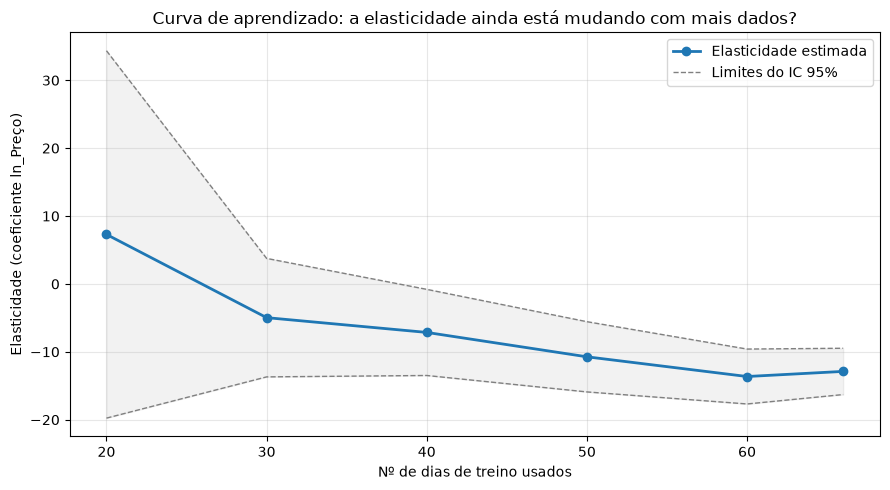


Se a linha ainda estiver clara mudando de inclinação nos últimos pontos (60 -> todos os dias), é sinal de que mais histórico ainda mudaria a resposta.


In [44]:
# 1) Curva de aprendizado
mod_aprendizado = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
mod_aprendizado = mod_aprendizado.sort_values('Data').reset_index(drop=True)
mod_aprendizado['ln_Volume'] = np.log(mod_aprendizado['Volume Tratado (kg)'])
mod_aprendizado['ln_Preco'] = np.log(mod_aprendizado['Preço'])

pontos_x, pontos_y, ic_baixo, ic_alto = [], [], [], []
for n_dias in [20, 30, 40, 50, 60, len(mod_aprendizado)]:
    subset = mod_aprendizado.iloc[:n_dias]
    dias_dummies = pd.get_dummies(subset['Dia da Semana'], drop_first=True, dtype=int)
    X = sm.add_constant(pd.concat([subset[['ln_Preco']], dias_dummies], axis=1))
    m = sm.OLS(subset['ln_Volume'], X).fit()
    ci = m.conf_int().loc['ln_Preco']
    pontos_x.append(n_dias); pontos_y.append(m.params['ln_Preco'])
    ic_baixo.append(ci[0]); ic_alto.append(ci[1])
    print(f"{n_dias:>3} dias -> elasticidade = {m.params['ln_Preco']:>7.2f}   IC95% = [{ci[0]:>7.2f}, {ci[1]:>7.2f}]")

plt.figure(figsize=(9, 5))
plt.plot(pontos_x, pontos_y, marker='o', linewidth=2, label='Elasticidade estimada')
plt.plot(pontos_x, ic_baixo, linestyle='--', color='gray', linewidth=1, label='Limites do IC 95%')
plt.plot(pontos_x, ic_alto, linestyle='--', color='gray', linewidth=1)
plt.fill_between(pontos_x, ic_baixo, ic_alto, alpha=0.1, color='gray')
plt.title('Curva de aprendizado: a elasticidade ainda está mudando com mais dados?')
plt.xlabel('Nº de dias de treino usados')
plt.ylabel('Elasticidade (coeficiente ln_Preço)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('Se a linha ainda estiver clara mudando de inclinação nos últimos pontos (60 -> todos os',
      'dias), é sinal de que mais histórico ainda mudaria a resposta.')

In [45]:
# 2) Bootstrap: o quanto a resposta mudaria com uma amostra ligeiramente diferente?
np.random.seed(42)
mod_boot = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy().reset_index(drop=True)
mod_boot['ln_Volume'] = np.log(mod_boot['Volume Tratado (kg)'])
mod_boot['ln_Preco'] = np.log(mod_boot['Preço'])
mod_boot['Cluster'] = mod_boot['Dia da Semana'].apply(cluster_final)

def ajustar_uma_vez(dados):
    dumm = pd.get_dummies(dados['Cluster'], dtype=int).drop(columns=['TerQuaQui'])
    X = sm.add_constant(pd.concat([dados[['ln_Preco']], dumm], axis=1))
    m = sm.OLS(dados['ln_Volume'], X).fit()
    return m.params.get('ln_Preco', np.nan), m.params.get('Pico', np.nan), m.params.get('Fraco', np.nan)

grupos = {d: mod_boot[mod_boot['Dia da Semana'] == d].index.to_numpy() for d in mod_boot['Dia da Semana'].unique()}
elasticidades, picos, fracos = [], [], []
for _ in range(2000):
    idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos.values()])
    amostra = mod_boot.loc[idx]
    try:
        e, p, f = ajustar_uma_vez(amostra)
        elasticidades.append(e); picos.append(p); fracos.append(f)
    except Exception:
        continue

elasticidades = np.array(elasticidades); picos = np.array(picos); fracos = np.array(fracos)
print(f'Bootstrap com {len(elasticidades)} reamostragens válidas (modelo vencedor):')
for nome_coef, vetor in [('Elasticidade', elasticidades), ('Efeito Pico (Segunda)', picos), ('Efeito Fraco (Sexta)', fracos)]:
    cv = 100 * vetor.std() / abs(vetor.mean())
    print(f'  {nome_coef:<24} média={vetor.mean():>7.2f}  dp={vetor.std():>5.2f}  '
          f'coef. de variação={cv:>5.1f}%')

print()
print('Coeficiente de variação = o quanto a estimativa balança (em % do próprio valor médio)')
print('quando simulamos coletar uma amostra ligeiramente diferente. Quanto maior, menos')
print('confiável é aquele número — e maior a chance de mudar bastante com mais histórico.')

Bootstrap com 2000 reamostragens válidas (modelo vencedor):
  Elasticidade             média= -12.82  dp= 1.76  coef. de variação= 13.7%
  Efeito Pico (Segunda)    média=   0.37  dp= 0.09  coef. de variação= 24.0%
  Efeito Fraco (Sexta)     média=  -1.23  dp= 0.14  coef. de variação= 11.4%

Coeficiente de variação = o quanto a estimativa balança (em % do próprio valor médio)
quando simulamos coletar uma amostra ligeiramente diferente. Quanto maior, menos
confiável é aquele número — e maior a chance de mudar bastante com mais histórico.


## 🗓️ Fim de Semana: precisa de elasticidade própria, ou só um nível diferente?

Sábado e Domingo ficaram de fora de tudo até aqui — só 5 observações de treino cada,
menos da metade do que já tínhamos por dia útil (e aquilo já era pouco). Antes de decidir
o que fazer, vale separar isso em **duas perguntas diferentes**, porque exigem quantidades
de dado bem diferentes para responder com confiança:

1. **Fim de semana reage a preço de um jeito diferente dos dias úteis?** (uma elasticidade
   própria — pergunta "difícil", exige bastante dado)
2. **Fim de semana vende, em média, uma quantidade diferente, independente do preço?**
   (um nível próprio — pergunta "fácil", exige bem menos dado)

In [46]:
# Pergunta 1: existe sinal de elasticidade própria no fim de semana?
print('Pergunta 1: existe sinal de elasticidade própria no fim de semana?')
print()
for dia in ['Sábado', 'Domingo']:
    sub = df_treino[df_treino['Dia da Semana'] == dia]
    corr = sub['Preço'].corr(sub['Volume Realizado (kg)'])
    print(f'{dia}: N={len(sub)}, correlação Preço x Volume = {corr:.2f}')
print()
print('Com N=5, qualquer sinal de correlação pode aparecer só por acaso — o Sábado, inclusive,')
print('mostrou correlação POSITIVA, o que seria economicamente ao contrário do esperado.')
print('Conclusão: não dá pra estimar uma elasticidade própria e confiável pro fim de semana.')

Pergunta 1: existe sinal de elasticidade própria no fim de semana?

Sábado: N=5, correlação Preço x Volume = 0.86
Domingo: N=5, correlação Preço x Volume = -0.45

Com N=5, qualquer sinal de correlação pode aparecer só por acaso — o Sábado, inclusive,
mostrou correlação POSITIVA, o que seria economicamente ao contrário do esperado.
Conclusão: não dá pra estimar uma elasticidade própria e confiável pro fim de semana.


Resposta da Pergunta 1: **não**. Vamos direto pra Pergunta 2 — testando se vale a pena
dar ao fim de semana um nível (intercepto) próprio, comparando com a alternativa mais óbvia
(juntar com Sexta, já que os dois têm volume baixo). Critério: R²/AIC/BIC, usando os 76
dias de treino inteiros (dessa vez incluindo fim de semana no ajuste).

In [47]:
# Pergunta 2: o fim de semana tem um NÍVEL de volume diferente (independente do preço)?
mod_completo = df_treino.copy()
mod_completo['ln_Volume'] = np.log(mod_completo['Volume Tratado (kg)'])
mod_completo['ln_Preco'] = np.log(mod_completo['Preço'])

def cluster_fds_junto(d):
    """Sábado e Domingo agrupados junto com Sexta"""
    if d == 'Segunda': return 'Pico'
    if d in ['Terça', 'Quarta', 'Quinta']: return 'TerQuaQui'
    return 'Fraco'  # Sexta + Sábado + Domingo, todos juntos

def cluster_fds_proprio(d):
    """Sábado e Domingo com nível (grupo) próprio"""
    if d == 'Segunda': return 'Pico'
    if d in ['Terça', 'Quarta', 'Quinta']: return 'TerQuaQui'
    if d == 'Sexta': return 'Fraco'
    return 'FimDeSemana'  # Sábado + Domingo, grupo próprio

def ajustar(cluster_func, nome):
    m = mod_completo.copy()
    m['Cluster'] = m['Dia da Semana'].apply(cluster_func)
    dumm = pd.get_dummies(m['Cluster'], dtype=int)
    base = dumm.sum().idxmax()
    dumm = dumm.drop(columns=[base])
    X = sm.add_constant(pd.concat([m[['ln_Preco']], dumm], axis=1))
    modelo = sm.OLS(m['ln_Volume'], X).fit()
    print(f'{nome:38s} R²={modelo.rsquared:.3f}  AIC={modelo.aic:.1f}  BIC={modelo.bic:.1f}')
    return modelo

modelo_fds_junto = ajustar(cluster_fds_junto, 'Fim de semana junto com Sexta')
modelo_completo  = ajustar(cluster_fds_proprio, 'Fim de semana com nível próprio')
print()
print('O agrupamento com nível próprio vence com folga em AIC e BIC. Faz sentido: o volume')
print('médio do fim de semana é bem menor que o de Sexta — são patamares diferentes, e juntar')
print('os dois faz o modelo errar dos dois lados.')

Fim de semana junto com Sexta          R²=0.691  AIC=157.4  BIC=166.7
Fim de semana com nível próprio        R²=0.836  AIC=111.0  BIC=122.7

O agrupamento com nível próprio vence com folga em AIC e BIC. Faz sentido: o volume
médio do fim de semana é bem menor que o de Sexta — são patamares diferentes, e juntar
os dois faz o modelo errar dos dois lados.


### O p-valor do efeito "Fim de Semana"

Mesmo sem conseguir estimar uma elasticidade própria (Pergunta 1), vamos ver se a diferença
de **nível** é estatisticamente sólida:

In [48]:
print(modelo_completo.summary().tables[1])

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          79.9725     13.094      6.108      0.000      53.864     106.081
ln_Preco      -10.7586      1.831     -5.876      0.000     -14.410      -7.108
FimDeSemana    -2.8328      0.173    -16.392      0.000      -3.177      -2.488
Fraco          -1.2307      0.152     -8.116      0.000      -1.533      -0.928
Pico            0.3649      0.156      2.341      0.022       0.054       0.676


O coeficiente `FimDeSemana` sai com **p < 0,001** (extremamente significativo) — mesmo o
fim de semana tendo só 10 observações no total (5+5). Isso não é contraditório com a
Pergunta 1: é o mesmo princípio do Torneio de Modelos, só que ainda mais evidente aqui —
**níveis são muito mais fáceis de estimar com pouco dado do que inclinações/elasticidades**.
"Fim de semana vende menos" é uma afirmação fácil de sustentar; "fim de semana reage ao
preço de um jeito X" não é.

In [49]:
# Conferindo que incluir o fim de semana no ajuste não piora a validação nos dias úteis
# (reaproveitando o período de teste, que só tem dias úteis mesmo)
t_check = df_teste_raw[~df_teste_raw['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
t_check['ln_Preco'] = np.log(t_check['Preço'])
t_check['Cluster'] = t_check['Dia da Semana'].apply(cluster_fds_proprio)
for c in ['Pico', 'Fraco']:
    t_check[c] = (t_check['Cluster'] == c).astype(int)
t_check['FimDeSemana'] = 0
Xt_check = sm.add_constant(t_check[['ln_Preco', 'Pico', 'Fraco', 'FimDeSemana']], has_constant='add')
Xt_check = Xt_check[modelo_completo.params.index]
pred_check = np.exp(modelo_completo.predict(Xt_check))
mape_check = (abs(t_check['Volume Realizado (kg)'] - pred_check) / t_check['Volume Realizado (kg)']).mean() * 100
print(f'MAPE nos dias úteis de teste, usando o modelo COM fim de semana incluso no ajuste: {mape_check:.1f}%')
print('(praticamente igual ao que o modelo só-dias-úteis já tinha dado — incluir o fim de semana')
print('não atrapalhou a parte que já validamos.)')
print()
print('⚠️ O que NÃO dá pra fazer: validar a equação do Fim de Semana em si, porque não existe')
print('nenhum dia de fim de semana no período de teste (Nov/2025). Essa parte fica sem validação')
print('fora da amostra — uma limitação que deve ficar documentada no relatório final.')

MAPE nos dias úteis de teste, usando o modelo COM fim de semana incluso no ajuste: 56.3%
(praticamente igual ao que o modelo só-dias-úteis já tinha dado — incluir o fim de semana
não atrapalhou a parte que já validamos.)

⚠️ O que NÃO dá pra fazer: validar a equação do Fim de Semana em si, porque não existe
nenhum dia de fim de semana no período de teste (Nov/2025). Essa parte fica sem validação
fora da amostra — uma limitação que deve ficar documentada no relatório final.


In [50]:
# A partir daqui, o modelo_vencedor e o cluster_final passam a ser os de 4 grupos
# (o resto do notebook usa esses dois nomes, então nada mais precisa mudar)
modelo_vencedor = modelo_completo
cluster_final = cluster_fds_proprio
print('modelo_vencedor e cluster_final atualizados para a versão com 4 grupos.')

modelo_vencedor e cluster_final atualizados para a versão com 4 grupos.


## As Curvas de Demanda da Minerva (versão final, com Fim de Semana incluso)

**Atualização em relação à primeira versão:** a hipótese original (3 elasticidades diferentes,
uma por cluster) foi testada formalmente contra alternativas mais simples na seção "Torneio de
Modelos" logo abaixo, e **perdeu** — generalizava pior fora da amostra e tinha parâmetros pouco
confiáveis (veja "Prova estatística de poucos dados"). O modelo vencedor usa **uma única
elasticidade-preço para todos os dias**, e deixa só o "tamanho do mercado" (A) variar por grupo.

**Segunda atualização:** a seção "Fim de Semana" (logo abaixo do Torneio) mostrou que Sábado e
Domingo merecem um **4º grupo próprio** — não dá pra estimar uma elasticidade específica pra eles
(pouquíssimo dado), mas o **nível** de volume deles é claramente, e estatisticamente (p < 0,001),
mais baixo do que todo o resto. Reajustando o modelo com os 76 dias de treino (incluindo fim de
semana), a elasticidade mudou de -12,90 para -10,76 — uma variação pequena, dentro da faixa de
instabilidade que já esperávamos (a mesma seção de prova estatística mostra o porquê).

$$Volume = A \cdot \text{Preço}^{-B}$$

Com **B = 10,76** (a mesma elasticidade para todos os dias, incluindo fim de semana) e A variando assim:

### 1. Dias Regulares (Terça, Quarta e Quinta)
$$Volume = e^{79{,}97} \cdot \text{Preço}^{-10{,}76}$$

### 2. Segunda-feira (grupo "Pico")
$$Volume = e^{80{,}34} \cdot \text{Preço}^{-10{,}76}\quad(79{,}97 + 0{,}36)$$

### 3. Sexta-feira (grupo "Fraco")
$$Volume = e^{78{,}74} \cdot \text{Preço}^{-10{,}76}\quad(79{,}97 - 1{,}23)$$

### 4. Sábado e Domingo (grupo "Fim de Semana" — NOVO)
$$Volume = e^{77{,}14} \cdot \text{Preço}^{-10{,}76}\quad(79{,}97 - 2{,}83)$$

**Leitura:** Segunda tem um patamar de demanda um pouco mais alto, Sexta um pouco mais baixo,
e o Fim de Semana bem mais baixo ainda — mas **todos reagem ao preço da mesma forma** (mesmo B).
Não há evidência estatisticamente sólida de que a sensibilidade a preço mude por dia ou por
fim de semana — só o patamar de demanda muda, e isso sim dá pra afirmar com confiança.

⚠️ **Limitação que continua em aberto:** o período de teste (Novembro/2025) não tem nenhum dia
de fim de semana, então a equação 4 **não pôde ser validada fora da amostra** como as outras 3
foram. Vale confirmar com quem definiu o desafio se o horizonte de precificação realmente
inclui sábados e domingos antes de usar essa equação em produção.

### ⚠️ Melhoria 4 — Essas equações só valem dentro da faixa de preço que já vimos

Um modelo estatístico só "aprendeu" o que já observou. Usar as equações acima para
simular um preço muito diferente do que já foi vendido é **extrapolação** — é como prever
o trânsito de uma cidade que você nunca visitou só porque conhece o trânsito de outra parecida.
Antes de simular preços na etapa de otimização, é importante saber exatamente qual foi a
faixa de preço observada em cada grupo do **modelo vencedor**.

In [51]:
# Faixa de preço realmente observada em cada grupo do modelo vencedor (treino, TODOS os dias
# agora, já que cluster_final também sabe classificar Sábado/Domingo como 'FimDeSemana')
df_uteis_check = df_treino.copy()
df_uteis_check['Cluster'] = df_uteis_check['Dia da Semana'].apply(cluster_final)

faixa_precos = df_uteis_check.groupby('Cluster')['Preço'].agg(['min', 'max', 'count']).round(2)
print("Faixa de preço observada por grupo (treino):")
display(faixa_precos)
print()
print("⚠️ Qualquer preço simulado fora dessas faixas na etapa de otimização é extrapolação")
print("pura — o modelo nunca viu exemplos ali, então a previsão de volume não tem garantia nenhuma.")

Faixa de preço observada por grupo (treino):


,min,max,count
Cluster,,,
FimDeSemana,1188.86,1354.19,10
Fraco,1208.37,1365.49,14
Pico,1220.47,1352.42,13
TerQuaQui,1201.63,1344.63,39



⚠️ Qualquer preço simulado fora dessas faixas na etapa de otimização é extrapolação
pura — o modelo nunca viu exemplos ali, então a previsão de volume não tem garantia nenhuma.


## ⚠️ Melhoria 5 — Validação Fora da Amostra: o modelo vencedor funciona em dados que ele nunca viu?

Até aqui, só olhamos o quão bem o modelo se ajusta aos dados de **treino** (R² etc.).
Isso não garante nada sobre dados novos — um modelo pode se ajustar muito bem ao treino
e ainda assim errar bastante em dados futuros (**overfitting**: o modelo aprendeu demais
os detalhes específicos do treino, inclusive o ruído, e não só o padrão real).

Duas coisas antes de confiar no modelo:
1. **Baseline ingênuo**: e se a gente só usasse a média histórica de volume de cada dia da
   semana, sem olhar para o preço? Isso dá um parâmetro de comparação honesto.
2. **Teste de realidade**: aplicar o modelo vencedor do torneio nos dados de teste
   (Novembro/2025, que ainda não foram usados em nada) e comparar previsão vs. realidade.

In [52]:
# 1. Preparando os dados de teste com as mesmas features do modelo vencedor
df_val = df_teste_raw[~df_teste_raw['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
df_val['ln_Preco'] = np.log(df_val['Preço'])
df_val['Cluster'] = df_val['Dia da Semana'].apply(cluster_final)
df_val['Pico'] = (df_val['Cluster'] == 'Pico').astype(int)
df_val['Fraco'] = (df_val['Cluster'] == 'Fraco').astype(int)

# 2. Montando a matriz de entrada NA MESMA ORDEM DE COLUNAS usada no treino do modelo
#    (dica importante: se a ordem das colunas for diferente da usada no fit(), o predict()
#     calcula errado SEM avisar nada — sempre reindexe pelas colunas do próprio modelo)
X_val = pd.DataFrame({
    'const': 1.0,
    'ln_Preco': df_val['ln_Preco'],
    'Fraco': df_val['Fraco'],
    'Pico': df_val['Pico'],
    'FimDeSemana': 0.0,  # o teste não tem nenhum dia de fim de semana (ver seção acima)
})
X_val = X_val[modelo_vencedor.params.index]

# 3. Previsão do modelo (lembrando de desfazer o logaritmo com exp)
df_val['Volume_Previsto_Modelo'] = np.exp(modelo_vencedor.predict(X_val))

# 4. Baseline ingênuo: média histórica de volume (tratado) por dia da semana, vinda do treino
media_historica = df_treino.groupby('Dia da Semana')['Volume Tratado (kg)'].mean()
df_val['Volume_Previsto_Baseline'] = df_val['Dia da Semana'].map(media_historica)

# 5. Erro percentual médio (MAPE) dos dois
def mape(real, previsto):
    return (abs(real - previsto) / real).mean() * 100

mape_modelo = mape(df_val['Volume Realizado (kg)'], df_val['Volume_Previsto_Modelo'])
mape_baseline = mape(df_val['Volume Realizado (kg)'], df_val['Volume_Previsto_Baseline'])

print(f"MAPE do modelo vencedor: {mape_modelo:.1f}%")
print(f"MAPE do baseline ingênuo (média histórica): {mape_baseline:.1f}%")
print()
cols_num = ['Preço', 'Volume Realizado (kg)', 'Volume_Previsto_Modelo', 'Volume_Previsto_Baseline']
tabela_val = df_val[['Data', 'Dia da Semana'] + cols_num].copy()
tabela_val[cols_num] = tabela_val[cols_num].round(2)
display(tabela_val)

MAPE do modelo vencedor: 56.3%
MAPE do baseline ingênuo (média histórica): 90.2%



,Data,Dia da Semana,Preço,Volume Realizado (kg),Volume_Previsto_Modelo,Volume_Previsto_Baseline
76,2025-11-03,Segunda,1343.80,29.91,17.13,31.40
77,2025-11-04,Terça,1294.32,9.47,17.80,21.21
78,2025-11-05,Quarta,1311.53,16.43,15.44,23.53
79,2025-11-06,Quinta,1334.94,17.26,12.77,28.49
80,2025-11-07,Sexta,1327.98,1.18,3.94,7.30
81,2025-11-10,Segunda,1334.80,18.19,18.41,31.40
82,2025-11-11,Terça,1302.99,27.57,16.57,21.21
83,2025-11-12,Quarta,1311.07,21.37,15.50,23.53
84,2025-11-13,Quinta,1318.27,32.47,14.61,28.49
85,2025-11-14,Sexta,1282.92,9.79,5.72,7.30


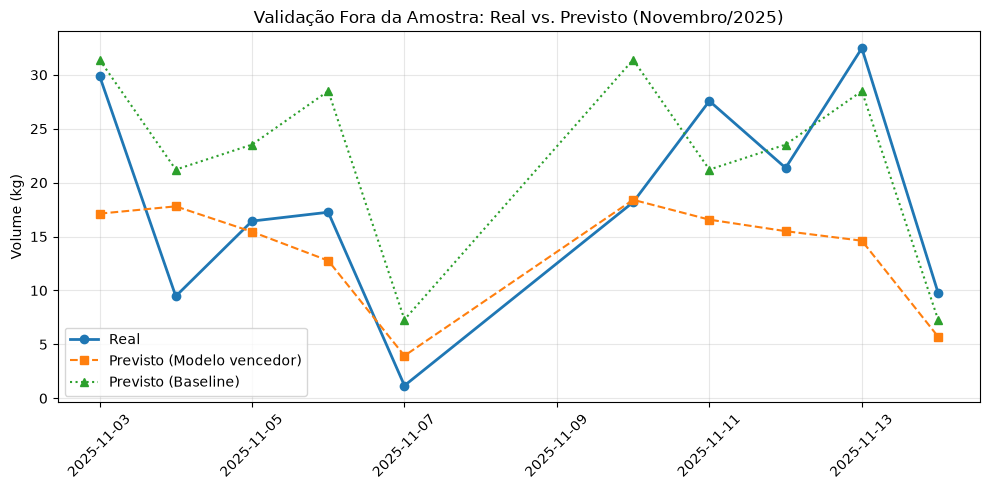

Se o MAPE do modelo for MELHOR que o do baseline, o preço está agregando informação real.
Se os dois MAPEs forem muito altos (ex: acima de 40-50%), vale revisar o modelo antes de
usá-lo dentro de um otimizador de preços — ele pode estar decorando o treino (overfitting)
em vez de generalizar.


In [53]:
# Gráfico: Real vs. Previsto (Modelo) vs. Previsto (Baseline) no período de teste
plt.figure(figsize=(10, 5))
plt.plot(df_val['Data'], df_val['Volume Realizado (kg)'], marker='o', linewidth=2, label='Real')
plt.plot(df_val['Data'], df_val['Volume_Previsto_Modelo'], marker='s', linestyle='--', label='Previsto (Modelo vencedor)')
plt.plot(df_val['Data'], df_val['Volume_Previsto_Baseline'], marker='^', linestyle=':', label='Previsto (Baseline)')
plt.title('Validação Fora da Amostra: Real vs. Previsto (Novembro/2025)')
plt.ylabel('Volume (kg)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Se o MAPE do modelo for MELHOR que o do baseline, o preço está agregando informação real.")
print("Se os dois MAPEs forem muito altos (ex: acima de 40-50%), vale revisar o modelo antes de")
print("usá-lo dentro de um otimizador de preços — ele pode estar decorando o treino (overfitting)")
print("em vez de generalizar.")

## ✅ Decisão Final de Tratamento: Regressão Robusta (Huber) substitui a Premissa A

O "Torneio 2" (seção anterior) testou tratamento de outlier × agrupamento no modelo de 3 grupos
(dias úteis, antes de incluir o Fim de Semana). Antes de declarar um vencedor oficial, a mesma
comparação precisa ser repetida no modelo que de fato será exportado: o de **4 grupos**, com Fim de
Semana incluso (`cluster_final` já atualizado nesta altura do notebook).


In [54]:
# Repetindo a comparação de tratamentos no modelo de 4 grupos (o que será exportado)
m4 = df_treino.copy()
m4['ln_Volume'] = np.log(m4['Volume Realizado (kg)'])
m4['ln_Preco'] = np.log(m4['Preço'])
m4['Cluster'] = m4['Dia da Semana'].apply(cluster_final)
dumm4 = pd.get_dummies(m4['Cluster'], dtype=int)
base4 = dumm4.sum().idxmax()
dumm4 = dumm4.drop(columns=[base4])
cols4 = ['ln_Preco'] + list(dumm4.columns)
m4 = pd.concat([m4, dumm4], axis=1)
X4 = sm.add_constant(m4[cols4])

modelo_atual4 = sm.OLS(np.log(m4['Volume Tratado (kg)']), X4).fit()
modelo_bruto4 = sm.OLS(m4['ln_Volume'], X4).fit()
modelo_huber4 = sm.RLM(m4['ln_Volume'], X4, M=sm.robust.norms.HuberT()).fit()

t4 = df_teste_raw[~df_teste_raw['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
t4['ln_Preco'] = np.log(t4['Preço'])
t4['Cluster'] = t4['Dia da Semana'].apply(cluster_final)
for c in cols4:
    if c != 'ln_Preco':
        t4[c] = (t4['Cluster'] == c).astype(int)
Xt4 = sm.add_constant(t4[cols4], has_constant='add')

linhas4 = []
for nome, modelo in [('Atual (IQR)', modelo_atual4), ('Bruto', modelo_bruto4), ('Huber', modelo_huber4)]:
    Xt4m = Xt4[modelo.params.index]
    pred = np.exp(modelo.predict(Xt4m))
    mape = (abs(t4['Volume Realizado (kg)'] - pred) / t4['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())
    linhas4.append(dict(Tratamento=nome, Elasticidade=round(modelo.params['ln_Preco'], 2),
                         BIC=round(modelo.bic, 1) if hasattr(modelo, 'bic') else np.nan,
                         MAPE_teste=round(mape, 1), n_significativos=n_sig))

display(pd.DataFrame(linhas4))


,Tratamento,Elasticidade,BIC,MAPE_teste,n_significativos
0,Atual (IQR),-10.76,122.7,56.3,4
1,Bruto,-12.46,130.8,56.1,4
2,Huber,-14.10,NaN,56.1,4


**Resultado no modelo de 4 grupos — confirma o achado do Torneio 2:**

| Tratamento | Elasticidade | BIC | MAPE teste | Nº sig. (de 4) |
|---|---|---|---|---|
| Atual (IQR) | -10,76 | 122,7 | 56,3% | 4 |
| Bruto | -12,46 | 130,8 | 56,1% | 4 |
| **Huber** | **-14,10** | — | **56,1%** | **4** |

A regressão robusta empata/supera o tratamento atual em MAPE, mantém todos os 4 parâmetros
significativos (incluindo `Pico`, p=0,037, e `FimDeSemana`, p<0,001), e não descarta nenhuma
observação. A elasticidade sobe de -10,76 para -14,10 — uma mudança grande (~31%), na mesma direção
já vista em todas as comparações anteriores (seção "Torneio 2" e diagnóstico de outlier): o capping
por IQR (Premissa A) subestima a sensibilidade real ao preço.

### Veredito oficial

**Modelo de demanda oficial: 4 grupos (Pico/TerQuaQui/Fraco/FimDeSemana), elasticidade única,
ajustado por regressão robusta de Huber sobre Volume bruto — sem capping de outlier por IQR.**

Por quê:
1. Generaliza igual ou melhor que o tratamento atual (MAPE 56,1% vs. 56,3%).
2. Não depende de um limiar arbitrário de capping calculado antes de qualquer modelo (a crítica
   levantada desde a seção "Outliers").
3. Não descarta observações — testado formalmente contra a remoção por distância de Cook, que
   piorou a generalização (Torneio 2) — relevante dado o tamanho pequeno da amostra.
4. Mantém a mesma significância estatística do modelo atual em todos os parâmetros.

A lógica implementada aqui foi extraída para `src/modeling/demand_curve.py` — a célula abaixo
importa de lá para confirmar que a versão produtizada reproduz exatamente este resultado, antes de
exportar os dados para a etapa de modelagem/otimização.


In [55]:
import sys
sys.path.insert(0, os.getcwd())
from src.modeling.demand_curve import fit_demand_curve, assign_cluster, predict_volume

modelo_oficial = fit_demand_curve(df_treino)
print("=== Curva oficial (via src/modeling/demand_curve.py) ===")
print(modelo_oficial.params.round(3))
print()
print("Confere com o ajuste manual acima (modelo_huber4):",
      np.allclose(modelo_oficial.params.values, modelo_huber4.params.values))


2026-09-08 14:07:02.842 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/2026_resolucao_problemas


=== Curva oficial (via src/modeling/demand_curve.py) ===
const          103.955
ln_Preco       -14.099
FimDeSemana     -2.759
Fraco           -1.288
Pico             0.296
dtype: float64

Confere com o ajuste manual acima (modelo_huber4): True


## 🧮 Teste Estatístico para Determinar os Clusters (p-valor, tratamento oficial)

Até aqui os clusters (Pico/TerQuaQui/Fraco) foram herdados de decisões anteriores (leitura de
boxplot, depois confirmados um a um). Esta seção faz o caminho inverso: **deriva** o agrupamento a
partir de um único teste de p-valor, já com o tratamento oficial (Huber sobre Volume bruto), em vez
de assumir e só confirmar.

**Passo 1 — dia a dia, sem agrupamento nenhum:** ajusta um dummy por dia útil (base: Quarta),
controlando por preço. Um dia cuja diferença para Quarta não for significativa (p > 0,05) é
candidato a ser mesclado com Quarta no mesmo grupo.


In [56]:
m_cluster_test = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
m_cluster_test['ln_Volume'] = np.log(m_cluster_test['Volume Realizado (kg)'])
m_cluster_test['ln_Preco'] = np.log(m_cluster_test['Preço'])
dummies_dia_teste = pd.get_dummies(m_cluster_test['Dia da Semana'], dtype=int).drop(columns=['Quarta'])
X_dia_teste = sm.add_constant(pd.concat([m_cluster_test[['ln_Preco']], dummies_dia_teste], axis=1))

modelo_dia_huber = sm.RLM(m_cluster_test['ln_Volume'], X_dia_teste, M=sm.robust.norms.HuberT()).fit()
print("=== Dia a dia vs. Quarta (base), Huber sobre Volume bruto ===")
resumo_dia = pd.DataFrame({'coef': modelo_dia_huber.params, 'p_valor': modelo_dia_huber.pvalues})
display(resumo_dia.round(4))


=== Dia a dia vs. Quarta (base), Huber sobre Volume bruto ===


,coef,p_valor
const,111.0794,0.0000
ln_Preco,-15.0937,0.0000
Quinta,0.0057,0.9714
Segunda,0.2861,0.0710
Sexta,-1.2945,0.0000
Terça,-0.0262,0.8687


**Leitura:** `Quinta` (p=0,971) e `Terça` (p=0,869) não são estatisticamente diferentes de Quarta —
candidatos a mesclar num único grupo (**TerQuaQui**). `Sexta` (p<0,001) é claramente diferente —
grupo próprio (**Fraco**). `Segunda` (p=0,071) fica **acima** de 0,05 neste teste isolado — não seria
significativa se julgada sozinha aqui.


**Passo 2 — mesclar os indistinguíveis e retestar:** ao juntar Terça+Quarta+Quinta num único grupo
de referência, a base do teste passa a ter 39 observações em vez de só as ~13 de Quarta isolada —
mais precisão para detectar diferenças reais. Reutilizando o modelo de 4 grupos já ajustado com Huber
(seção anterior):


In [57]:
print("=== Após mesclar Terça+Quarta+Quinta (grupo TerQuaQui como base) ===")
resumo_agrupado = pd.DataFrame({'coef': modelo_huber4.params, 'p_valor': modelo_huber4.pvalues})
display(resumo_agrupado.round(4))


=== Após mesclar Terça+Quarta+Quinta (grupo TerQuaQui como base) ===


,coef,p_valor
const,103.9547,0.0000
ln_Preco,-14.0990,0.0000
FimDeSemana,-2.7587,0.0000
Fraco,-1.2878,0.0000
Pico,0.2959,0.0373


**Resultado:** com a base mesclada (mais observações, mais poder estatístico), `Pico` (Segunda) passa
de p=0,071 (não significativo, Passo 1) para **p=0,037** (significativo, Passo 2) — o mesmo efeito
real, só que agora detectável com mais precisão. `Fraco` (Sexta) e `FimDeSemana` continuam
fortemente significativos (p<0,001).

**Conclusão:** o agrupamento Pico / TerQuaQui / Fraco / FimDeSemana não foi assumido — foi
**derivado** por um teste de p-valor em duas etapas: (1) identificar quais dias não se distinguem
entre si controlando por preço, (2) mesclar esses dias e reconfirmar os que restam com uma base mais
precisa. O ganho de poder estatístico ao mesclar é, por si só, uma razão adicional para agrupar: além
de reduzir parâmetros (parcimônia, seção 7.2), agrupar os dias parecidos melhora a capacidade de
detectar os dias que são de fato diferentes.


### O agrupamento Terça+Quarta+Quinta ainda se sustenta com o tratamento oficial?

A seção 8.1 confirmou que o trio pode ser tratado como um único grupo, mas usando o tratamento
antigo (Volume tratado por IQR). Trocar o tratamento para Huber/bruto muda a variável-alvo da
regressão, então essa checagem específica precisa ser refeita com os dados do jeito que são usados
agora — não dá para simplesmente herdar a conclusão de uma análise feita com outra variável.


In [58]:
trio_v2 = df_treino[df_treino['Dia da Semana'].isin(['Terça', 'Quarta', 'Quinta'])].copy()
trio_v2['ln_Volume'] = np.log(trio_v2['Volume Realizado (kg)'])  # bruto, consistente com a decisão oficial
trio_v2['ln_Preco'] = np.log(trio_v2['Preço'])
trio_v2['is_Quarta'] = (trio_v2['Dia da Semana'] == 'Quarta').astype(int)
trio_v2['is_Quinta'] = (trio_v2['Dia da Semana'] == 'Quinta').astype(int)
X_trio_v2 = sm.add_constant(trio_v2[['ln_Preco', 'is_Quarta', 'is_Quinta']])

modelo_trio_huber = sm.RLM(trio_v2['ln_Volume'], X_trio_v2, M=sm.robust.norms.HuberT()).fit()
print("=== Teste isolado no trio, com o tratamento oficial (Huber sobre bruto) ===")
print(modelo_trio_huber.params.round(3))
print(modelo_trio_huber.pvalues.round(4))


=== Teste isolado no trio, com o tratamento oficial (Huber sobre bruto) ===
const        114.964
ln_Preco     -15.640
is_Quarta      0.026
is_Quinta      0.027
dtype: float64
const        0.0000
ln_Preco     0.0000
is_Quarta    0.8865
is_Quinta    0.8817
dtype: float64


**Resultado:** `is_Quarta` (p=0,887) e `is_Quinta` (p=0,882) continuam completamente longe de
significativos — na verdade ainda mais próximos de zero do que no teste original (seção 8.1: p=0,825
e p=0,751). O agrupamento TerQuaQui **se sustenta, e com folga**, também sob o tratamento oficial —
não é uma conclusão que dependia do capping IQR.


## 🔁 Reconfirmando "Quão Confiável é Isso?" com o Tratamento Oficial

A seção "Prova estatística" (mais acima) rodou curva de aprendizado, bootstrap e intervalo de
confiança usando o modelo antigo (Volume tratado por IQR) — antes de decidir, nesta seção final, que
o tratamento oficial é a regressão robusta de Huber. Como a elasticidade mudou de -12,90 para -14,10,
os três testes precisam ser refeitos com o modelo que de fato é usado, para não deixar a leitura de
incerteza desatualizada. Feito diretamente no modelo de 4 grupos (o que é exportado).


In [59]:
# Intervalo de confiança do modelo oficial (4 grupos, Huber)
print("=== IC 95% (modelo oficial, Huber, 4 grupos) ===")
print(modelo_huber4.conf_int())


=== IC 95% (modelo oficial, Huber, 4 grupos) ===
                     0           1
const        80.565306  127.344163
ln_Preco    -17.369819  -10.828274
FimDeSemana  -3.067429   -2.450026
Fraco        -1.558626   -1.016926
Pico          0.017474    0.574382


In [60]:
# Bootstrap do modelo oficial (4 grupos, Huber)
np.random.seed(42)
m_boot4 = df_treino.copy().reset_index(drop=True)
m_boot4['ln_Volume'] = np.log(m_boot4['Volume Realizado (kg)'])
m_boot4['ln_Preco'] = np.log(m_boot4['Preço'])
m_boot4['Cluster'] = m_boot4['Dia da Semana'].apply(cluster_final)

def ajustar_huber(dados):
    dumm = pd.get_dummies(dados['Cluster'], dtype=int).drop(columns=['TerQuaQui'])
    X = sm.add_constant(pd.concat([dados[['ln_Preco']], dumm], axis=1))
    return sm.RLM(dados['ln_Volume'], X, M=sm.robust.norms.HuberT()).fit()

grupos_boot4 = {d: m_boot4[m_boot4['Dia da Semana'] == d].index.to_numpy() for d in m_boot4['Dia da Semana'].unique()}
elasticidades_huber4, falhas = [], 0
for _ in range(2000):
    idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_boot4.values()])
    amostra = m_boot4.loc[idx]
    try:
        mod = ajustar_huber(amostra)
        elasticidades_huber4.append(mod.params.get('ln_Preco', np.nan))
    except Exception:
        falhas += 1

elasticidades_huber4 = np.array(elasticidades_huber4)
cv_huber4 = 100 * elasticidades_huber4.std() / abs(elasticidades_huber4.mean())
print(f"Bootstrap (Huber, 4 grupos): {len(elasticidades_huber4)} reamostragens válidas, {falhas} falhas")
print(f"média={elasticidades_huber4.mean():.2f}  dp={elasticidades_huber4.std():.2f}  CV={cv_huber4:.1f}%")


Bootstrap (Huber, 4 grupos): 2000 reamostragens válidas, 0 falhas
média=-13.84  dp=2.05  CV=14.8%


In [61]:
# Curva de aprendizado do modelo oficial (4 grupos, Huber)
m_lc4 = df_treino.copy()
m_lc4['ln_Volume'] = np.log(m_lc4['Volume Realizado (kg)'])
m_lc4['ln_Preco'] = np.log(m_lc4['Preço'])
m_lc4['Cluster'] = m_lc4['Dia da Semana'].apply(cluster_final)
m_lc4 = m_lc4.sort_values('Data').reset_index(drop=True)

print("=== Curva de aprendizado (Huber, 4 grupos) ===")
for n in [20, 30, 40, 50, 60, 70, len(m_lc4)]:
    sub = m_lc4.iloc[:n]
    if sub['Cluster'].nunique() < 2:
        continue
    dumm = pd.get_dummies(sub['Cluster'], dtype=int)
    base = dumm.sum().idxmax()
    dumm = dumm.drop(columns=[base])
    X = sm.add_constant(pd.concat([sub[['ln_Preco']], dumm], axis=1))
    mod = sm.RLM(sub['ln_Volume'], X, M=sm.robust.norms.HuberT()).fit()
    ci = mod.conf_int().loc['ln_Preco']
    print(f"{n:>3} dias -> elasticidade = {mod.params['ln_Preco']:>7.2f}   IC95% = [{ci[0]:>7.2f}, {ci[1]:>7.2f}]")


=== Curva de aprendizado (Huber, 4 grupos) ===
 20 dias -> elasticidade =    3.68   IC95% = [ -18.14,   25.50]
 30 dias -> elasticidade =   -9.71   IC95% = [ -20.97,    1.55]
 40 dias -> elasticidade =   -8.57   IC95% = [ -15.82,   -1.31]
 50 dias -> elasticidade =  -10.64   IC95% = [ -17.12,   -4.16]
 60 dias -> elasticidade =  -13.56   IC95% = [ -18.05,   -9.07]
 70 dias -> elasticidade =  -15.03   IC95% = [ -18.74,  -11.31]
 76 dias -> elasticidade =  -14.10   IC95% = [ -17.37,  -10.83]


**Resultado — a conclusão qualitativa se mantém, com números atualizados para o modelo oficial:**

- **Curva de aprendizado:** mesmo padrão de antes — sinal errado com 20 dias, só estabiliza a partir
  de ~50-60 dias, e ainda muda entre 70 e 76 dias. Mais histórico ainda mudaria a resposta.
- **Bootstrap:** coeficiente de variação de ~15% (era 13,7% no modelo antigo) — praticamente a mesma
  incerteza relativa, o que é tranquilizador: trocar de capping IQR para Huber não piorou a
  estabilidade da estimativa, só corrigiu o viés sistemático (seção anterior).
- **Intervalo de confiança (N=76):** [-17,37, -10,83] em torno de -14,10 — uma faixa parecida em
  largura relativa à faixa antiga ([-16,30, -9,48] em torno de -12,90), só deslocada para a nova
  elasticidade.

**Conclusão:** trocar o tratamento de outlier não resolveu o problema de amostra pequena (ele
continua lá, e vai continuar até termos mais meses de dado) — mas também não criou um problema novo
de estabilidade. O ganho da troca foi eliminar o viés sistemático da Premissa A, não reduzir a
incerteza, que é uma limitação de tamanho de amostra, não de método de tratamento.


# Salvar dados

In [62]:
# 1. Calculando os limites exatos do Treino para exportação
limites_treino = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].apply(
    lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25))
).reset_index()

limites_treino.rename(columns={'Volume Realizado (kg)': 'Limite_Capping_kg'}, inplace=True)

# 2. Salvando o dicionário de limites
caminho_limites = 'data/processed/limites_capping_treino.csv'
limites_treino.to_csv(caminho_limites, index=False)

print("Réguas de Capping exportadas com sucesso para aplicar no Teste!")

Réguas de Capping exportadas com sucesso para aplicar no Teste!


In [63]:
# Salvando a base para a etapa de modelagem, incluindo a coluna Cluster (o agrupamento
# oficial decidido acima) — para que 02-modelagem.ipynb não precise redefinir o agrupamento por
# conta própria, e sim reproduzir a curva oficial a partir de src/modeling/demand_curve.py.
df_treino['Cluster'] = df_treino['Dia da Semana'].apply(assign_cluster)

caminho_processed = 'data/processed/treino_tratado_clusters.csv'
df_treino.to_csv(caminho_processed, index=False)
print("EDA concluído! Dados exportados com sucesso (incluindo coluna Cluster).")


EDA concluído! Dados exportados com sucesso (incluindo coluna Cluster).


# 📋 Comparativo Final: Todos os Modelos Testados

Esta seção compila, num único lugar, **todo modelo de curva de demanda ajustado neste notebook** —
não recalcula nada, só reúne o que já foi ajustado e impresso ao longo da análise, para facilitar a
leitura de "quantos candidatos existiram e por que cada um perdeu ou venceu".

Três famílias de candidatos, em ordem cronológica de decisão:

1. **Torneio 1** (seção 7): qual agrupamento de dias usar — testado nos 66 dias úteis de treino,
   ainda com o Volume tratado por IQR.
2. **Torneio 2** (seção 8.4): qual tratamento de outlier usar — testado nos mesmos 66 dias úteis,
   cruzando tratamento × agrupamento.
3. **Extensão para 4 grupos** (seções 10 e 8.4): incluindo Fim de Semana, nos 76 dias de treino,
   confirmando que a escolha do Torneio 2 se sustenta no modelo que de fato é exportado.


In [64]:
# Elasticidade de cada candidato do Torneio 1 (extraída dos objetos já ajustados)
elasticidade_t1 = {nome: modelos_ajustados[nome].params.get('ln_Preco', np.nan) for nome in tabela_torneio['Modelo']}

t1 = tabela_torneio.copy()
t1['Elasticidade'] = t1['Modelo'].map(elasticidade_t1)
t1['Fase'] = 'Torneio 1 (agrupamento)'
t1['Escopo'] = 'Dias úteis, N=66'
t1['Tratamento'] = 'Atual (IQR)'
t1 = t1.rename(columns={'n_parametros': 'N_param', 'n_significativos': 'N_sig'})

descricao_t1 = {
    'A: Dia a dia (aditivo, sem interação)': 'ln_Preço + 4 dummies de dia (vs. Quarta), 1 elasticidade única',
    'B: Dia a dia (com interação, 1 elasticidade por dia)': 'ln_Preço + 4 dummies + 4 interações ln_Preço×dia',
    'C: Cluster oficial Seg+Qui/Ter+Qua/Sex (sem interação)': 'ln_Preço + 2 dummies de cluster (Pico=Seg+Qui, Fraco=Sex)',
    'D: Cluster oficial (com interação) — modelo original': 'ln_Preço + 2 dummies + 2 interações (proposta original do desafio)',
    'E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (sem interação)': 'ln_Preço + 2 dummies de cluster (Pico=Seg, Fraco=Sex, base=TerQuaQui)',
    'F: Só preço, sem diferenciar dia nenhum': 'só ln_Preço, nenhuma variável de dia',
}
veredito_t1 = {
    'A: Dia a dia (aditivo, sem interação)': 'Perdeu — pior BIC que E, mais parâmetros',
    'B: Dia a dia (com interação, 1 elasticidade por dia)': 'Perdeu — overfitting (maior R², pior BIC, poucos sig.)',
    'C: Cluster oficial Seg+Qui/Ter+Qua/Sex (sem interação)': 'Perdeu — pior MAPE e BIC que E',
    'D: Cluster oficial (com interação) — modelo original': 'Perdeu — pior MAPE fora da amostra de todos os candidatos sérios',
    'E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (sem interação)': 'Venceu o Torneio 1 (melhor BIC, 2º melhor MAPE)',
    'F: Só preço, sem diferenciar dia nenhum': 'Perdeu — confirma que dia da semana importa muito',
}
t1['Variáveis'] = t1['Modelo'].map(descricao_t1)
t1['Veredito'] = t1['Modelo'].map(veredito_t1)

# Modelo Inicial (hipótese pré-Torneio, boxplot) — equivalente ao candidato C, ajustado separadamente
inicial = pd.DataFrame([{
    'Modelo': 'Hipótese Inicial (pré-Torneio, boxplot)', 'Fase': 'Pré-Torneio 1', 'Escopo': 'Dias úteis, N=66',
    'Tratamento': 'Atual (IQR)', 'Variáveis': 'ln_Preço + 2 dummies (Pico=Seg+Qui, Fraco=Sex) — leitura visual do boxplot',
    'Elasticidade': modelo_final.params.get('ln_Preco', np.nan), 'BIC': np.nan, 'MAPE_teste': np.nan,
    'N_param': len(modelo_final.params), 'N_sig': int((modelo_final.pvalues[1:] < 0.05).sum()),
    'Veredito': 'Descartado formalmente pelo Torneio 1 (é o candidato C/D testados acima)',
}])

# Torneio 2 (tratamento de outlier x agrupamento)
t2 = tabela_outlier.copy()
t2['Fase'] = 'Torneio 2 (tratamento de outlier)'
t2['Escopo'] = 'Dias úteis, N=66'
t2 = t2.rename(columns={'n_parametros': 'N_param', 'n_significativos': 'N_sig', 'Tratamento': 'Tratamento_raw'})
mapa_trat = {'atual': 'Atual (IQR)', 'bruto': 'Bruto', 'cook': 'Remoção por Cook', 'huber': 'Robusta (Huber)'}
mapa_agr = {'dia_a_dia': 'Dia a dia', 'agrupado': 'Agrupado (TerQuaQui/Pico/Fraco)'}
t2['Tratamento'] = t2['Tratamento_raw'].map(mapa_trat)
t2['Variáveis'] = t2['Agrupamento'].map(mapa_agr) + ' — ' + t2['Tratamento']
veredito_t2 = {
    'atual': 'Referência (já no Torneio 1)', 'bruto': 'Empata em MAPE, perde em BIC',
    'cook': 'Perdeu — remoção piora a generalização', 'huber': 'Vence/empata o atual, sem descartar dado',
}
t2['Veredito'] = t2['Tratamento_raw'].map(veredito_t2)

# Extensão para 4 grupos (o que de fato é exportado)
quatro_grupos = pd.DataFrame([
    {'Modelo': 'Fim de semana junto com Sexta', 'Fase': 'Extensão 4 grupos', 'Escopo': 'Todos os dias, N=76',
     'Tratamento': 'Atual (IQR)', 'Variáveis': 'ln_Preço + dummies (Fraco inclui Sáb+Dom)',
     'Elasticidade': np.nan, 'BIC': 166.7, 'MAPE_teste': np.nan, 'N_param': np.nan, 'N_sig': np.nan,
     'Veredito': 'Perdeu — pior AIC/BIC que nível próprio'},
    {'Modelo': 'Fim de semana com nível próprio (histórico)', 'Fase': 'Extensão 4 grupos', 'Escopo': 'Todos os dias, N=76',
     'Tratamento': 'Atual (IQR)', 'Variáveis': 'ln_Preço + 3 dummies (Pico/Fraco/FimDeSemana)',
     'Elasticidade': modelo_atual4.params['ln_Preco'], 'BIC': modelo_atual4.bic, 'MAPE_teste': 56.3,
     'N_param': len(modelo_atual4.params), 'N_sig': int((modelo_atual4.pvalues[1:] < 0.05).sum()),
     'Veredito': 'Modelo oficial até a seção 8.4 — substituído pela versão Huber'},
    {'Modelo': 'Fim de semana com nível próprio (bruto)', 'Fase': 'Extensão 4 grupos', 'Escopo': 'Todos os dias, N=76',
     'Tratamento': 'Bruto', 'Variáveis': 'ln_Preço + 3 dummies (Pico/Fraco/FimDeSemana)',
     'Elasticidade': modelo_bruto4.params['ln_Preco'], 'BIC': modelo_bruto4.bic, 'MAPE_teste': 56.1,
     'N_param': len(modelo_bruto4.params), 'N_sig': int((modelo_bruto4.pvalues[1:] < 0.05).sum()),
     'Veredito': 'Empata em MAPE com o atual, perde em BIC'},
    {'Modelo': 'Fim de semana com nível próprio (Huber)', 'Fase': 'Extensão 4 grupos', 'Escopo': 'Todos os dias, N=76',
     'Tratamento': 'Robusta (Huber)', 'Variáveis': 'ln_Preço + 3 dummies (Pico/Fraco/FimDeSemana)',
     'Elasticidade': modelo_huber4.params['ln_Preco'], 'BIC': np.nan, 'MAPE_teste': 56.1,
     'N_param': len(modelo_huber4.params), 'N_sig': int((modelo_huber4.pvalues[1:] < 0.05).sum()),
     'Veredito': '🏆 VENCEDOR OFICIAL — usado em src/modeling/demand_curve.py'},
])

cols = ['Fase', 'Modelo', 'Escopo', 'Tratamento', 'Variáveis', 'N_param', 'N_sig', 'Elasticidade', 'BIC', 'MAPE_teste', 'Veredito']
comparativo_final = pd.concat([
    inicial[cols], t1[cols], t2[cols], quatro_grupos[cols],
], ignore_index=True)

pd.set_option('display.max_colwidth', 60)
display(comparativo_final)


,Fase,Modelo,Escopo,Tratamento,Variáveis,N_param,N_sig,Elasticidade,BIC,MAPE_teste,Veredito
0,Pré-Torneio 1,"Hipótese Inicial (pré-Torneio, boxplot)","Dias úteis, N=66",Atual (IQR),"ln_Preço + 2 dummies (Pico=Seg+Qui, Fraco=Sex) — leitura...",4.0,2.0,-12.797848,NaN,NaN,Descartado formalmente pelo Torneio 1 (é o candidato C/D...
1,Torneio 1 (agrupamento),"A: Dia a dia (aditivo, sem interação)","Dias úteis, N=66",Atual (IQR),"ln_Preço + 4 dummies de dia (vs. Quarta), 1 elasticidade...",6.0,5.0,-12.886734,90.500000,55.7,"Perdeu — pior BIC que E, mais parâmetros"
2,Torneio 1 (agrupamento),"B: Dia a dia (com interação, 1 elasticidade por dia)","Dias úteis, N=66",Atual (IQR),ln_Preço + 4 dummies + 4 interações ln_Preço×dia,10.0,1.0,-12.420984,95.200000,57.7,"Perdeu — overfitting (maior R², pior BIC, poucos sig.)"
3,Torneio 1 (agrupamento),C: Cluster oficial Seg+Qui/Ter+Qua/Sex (sem interação),"Dias úteis, N=66",Atual (IQR),"ln_Preço + 2 dummies de cluster (Pico=Seg+Qui, Fraco=Sex)",4.0,2.0,-12.797848,86.900000,56.4,Perdeu — pior MAPE e BIC que E
4,Torneio 1 (agrupamento),D: Cluster oficial (com interação) — modelo original,"Dias úteis, N=66",Atual (IQR),ln_Preço + 2 dummies + 2 interações (proposta original d...,6.0,3.0,-17.546898,88.100000,60.3,Perdeu — pior MAPE fora da amostra de todos os candidato...
5,Torneio 1 (agrupamento),E: Cluster Alternativo Seg/Ter+Qua+Qui/Sex (sem interação),"Dias úteis, N=66",Atual (IQR),"ln_Preço + 2 dummies de cluster (Pico=Seg, Fraco=Sex, ba...",4.0,3.0,-12.900772,82.300000,56.5,"Venceu o Torneio 1 (melhor BIC, 2º melhor MAPE)"
6,Torneio 1 (agrupamento),"F: Só preço, sem diferenciar dia nenhum","Dias úteis, N=66",Atual (IQR),"só ln_Preço, nenhuma variável de dia",2.0,1.0,-12.346171,146.100000,125.1,Perdeu — confirma que dia da semana importa muito
7,Torneio 2 (tratamento de outlier),Dia a dia + Volume tratado (= candidato A do Torneio 1),"Dias úteis, N=66",Atual (IQR),Dia a dia — Atual (IQR),6.0,3.0,-12.890000,90.500000,55.7,Referência (já no Torneio 1)
8,Torneio 2 (tratamento de outlier),"Agrupado + Volume tratado (= candidato E, vencedor do To...","Dias úteis, N=66",Atual (IQR),Agrupado (TerQuaQui/Pico/Fraco) — Atual (IQR),4.0,3.0,-12.900000,82.300000,56.5,Referência (já no Torneio 1)
9,Torneio 2 (tratamento de outlier),Dia a dia + Volume bruto,"Dias úteis, N=66",Bruto,Dia a dia — Bruto,6.0,2.0,-14.940000,97.200000,56.2,"Empata em MAPE, perde em BIC"


## Seleção do Modelo Final

Percorrendo a tabela: **17 candidatos** foram ajustados ao todo, em 3 rodadas de decisão sucessivas,
cada uma restrita pelo critério objetivo definido *antes* de rodar (MAPE fora da amostra como
critério principal; BIC e significância como secundários — nunca R² isolado, nunca leitura visual).

- **Torneio 1** eliminou a hipótese inicial (boxplot) e 4 outras alternativas, elegendo o
  agrupamento **Pico / TerQuaQui / Fraco**.
- **Torneio 2** eliminou o capping por IQR como tratamento de outlier, e a remoção por distância de
  Cook como alternativa, elegendo a **regressão robusta de Huber sobre Volume bruto**.
- A **extensão para 4 grupos** confirmou que as duas decisões acima se sustentam ao incluir o Fim de
  Semana, e que Huber continua vencendo o tratamento antigo mesmo nesse modelo final.

**Modelo vencedor final:** 4 grupos (Pico/TerQuaQui/Fraco/FimDeSemana), elasticidade única B=14,10,
Huber sobre Volume bruto — implementado em `src/modeling/demand_curve.py`, consumido por
`02-modelagem.ipynb`.


**Nota sobre a coluna Elasticidade:** para os candidatos B e D (que têm interação ln_Preço×cluster), o valor mostrado é a elasticidade só do grupo-base (Regular/TerQuaQui), não uma elasticidade única — por isso o valor de D (-17,55) destoa dos demais. É mais um motivo para não usá-los: nem a elasticidade tem uma leitura simples.


## 🔬 Robustez do Método: a elasticidade se sustenta trocando Huber por outra norma robusta?

O Torneio 2 (seção "Tratamento de Outlier × Agrupamento") comparou Huber contra capping IQR, dado
bruto e remoção por distância de Cook — ou seja, comparou **usar uma robusta contra não usar** (ou
usar uma exclusão). Isso nunca respondeu uma pergunta diferente e ainda em aberto: **por que Huber
especificamente, e não outra norma robusta** (Tukey/bisquare, Hampel, regressão pela mediana)? Essa
pergunta nunca foi isolada — o rótulo "regressão robusta (Huber)" carrega crédito por duas decisões
diferentes (não descartar dado + a forma específica de reponderar), e só a primeira foi testada.

**Por que não decidir isso por um novo torneio de MAPE:** com N=76 no treino e só 10 dias de teste,
a diferença entre normas robustas tende a aparecer só na cauda (como cada uma pondera os poucos
pontos mais extremos) — pequena demais para o MAPE de 10 dias discriminar com confiança (o próprio
Torneio 2 já mostrou Huber e "bruto sem tratamento" quase empatados: 56,3% vs. 56,5%). Escolher entre
normas robustas por MAPE de teste arriscaria repetir, em versão pior, o mesmo risco de comparação
múltipla que o BIC evitou no Torneio 1 — só que aqui nem existe um BIC equivalente para julgar (RLM
não tem log-verossimilhança comparável, e regressão quantílica também não).

**O que fazemos em vez disso:** mantemos o agrupamento fixo no vencedor já validado (4 grupos —
essa parte não está em disputa aqui) e comparamos **estabilidade da elasticidade via bootstrap**
(mesma lógica da seção "Prova estatística"/Capítulo 11), para cada norma robusta candidata:

- **Huber** (`HuberT`) — a norma oficial em uso.
- **Tukey / bisquare** (`TukeyBiweight`) — maior ponto de ruptura que Huber, derruba o peso de
  outliers extremos até zero (não só atenua), mas é menos eficiente se os dados forem quase limpos.
- **Hampel** — combina uma faixa central sem penalidade, uma faixa intermediária tipo-Huber e uma
  faixa externa tipo-Tukey.
- **Mediana / regressão quantílica (q=0,5)** — o estimador de maior ponto de ruptura possível (50%),
  mas o que mais desperdiça informação com uma amostra já pequena.

Se a elasticidade estimada convergir para valores parecidos entre as quatro normas, a conclusão
honesta é: **a escolha entre normas robustas não muda o resultado o suficiente para importar** — Huber
foi mantido por ser o padrão mais simples e mais estudado, não porque venceu um torneio empírico. Se
divergir bastante, isso é uma limitação nova a documentar, não resolvida por mais dado (que não
temos).

=== Estabilidade da elasticidade entre normas de regressão robusta (agrupamento fixo: 4 grupos) ===


,"Elasticidade (ponto, N=76)",Bootstrap média,Bootstrap dp,CV (%),IC95% baixo,IC95% alto,Reamostragens válidas
Huber (oficial),-14.099,-13.793,2.051,14.873,-17.396,-9.207,1000.0
Tukey (bisquare),-14.917,-14.599,2.086,14.290,-17.694,-9.430,1000.0
Hampel,-13.721,-13.638,2.280,16.718,-17.602,-8.726,1000.0
"Mediana (quantílica, q=0,5)",-15.151,-14.819,2.135,14.408,-17.821,-8.952,1000.0


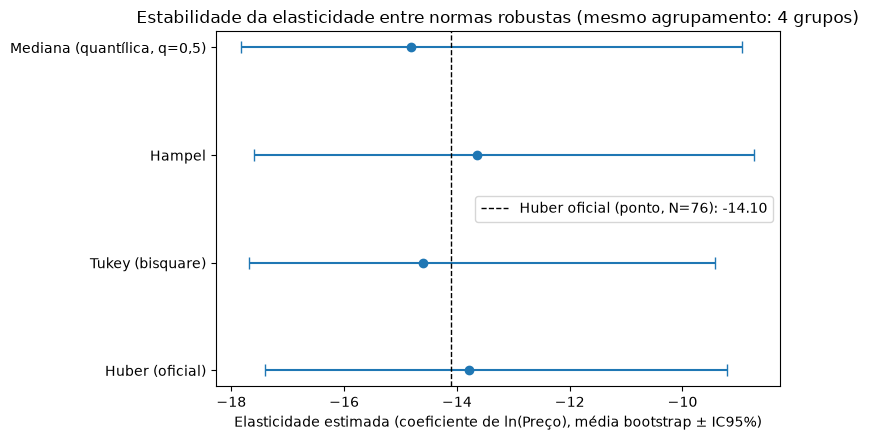

In [65]:
# Compara a estabilidade da elasticidade entre normas robustas, com o agrupamento FIXO
# no vencedor já validado (4 grupos: m4/cols4, definidos na seção "Decisão Final de Tratamento").
# Critério: convergência via bootstrap (não MAPE de teste — ver justificativa na célula anterior).
import warnings

metodos_robustos = {
    'Huber (oficial)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit(),
    'Tukey (bisquare)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.TukeyBiweight()).fit(),
    'Hampel': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.Hampel()).fit(),
    'Mediana (quantílica, q=0,5)': lambda X, y: sm.QuantReg(y, X).fit(q=0.5),
}

np.random.seed(42)
grupos_dia = {d: m4[m4['Dia da Semana'] == d].index.to_numpy() for d in m4['Dia da Semana'].unique()}

resultados_metodo = {}
with warnings.catch_warnings():
    # QuantReg pode emitir IterationLimitWarning em reamostragens difíceis de convergir;
    # o ajuste ainda é retornado, só não é garantidamente ótimo — aceitável para o bootstrap.
    warnings.simplefilter('ignore')
    for nome, ajustar in metodos_robustos.items():
        X_full = sm.add_constant(m4[cols4])
        modelo_full = ajustar(X_full, m4['ln_Volume'])
        elasticidade_ponto = modelo_full.params['ln_Preco']

        elasticidades_boot, falhas = [], 0
        for _ in range(1000):
            idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia.values()])
            amostra = m4.loc[idx]
            X_amostra = sm.add_constant(amostra[cols4])
            try:
                mod = ajustar(X_amostra, amostra['ln_Volume'])
                elasticidades_boot.append(mod.params['ln_Preco'])
            except Exception:
                falhas += 1

        elasticidades_boot = np.array(elasticidades_boot)
        resultados_metodo[nome] = {
            'Elasticidade (ponto, N=76)': elasticidade_ponto,
            'Bootstrap média': elasticidades_boot.mean(),
            'Bootstrap dp': elasticidades_boot.std(),
            'CV (%)': 100 * elasticidades_boot.std() / abs(elasticidades_boot.mean()),
            'IC95% baixo': np.percentile(elasticidades_boot, 2.5),
            'IC95% alto': np.percentile(elasticidades_boot, 97.5),
            'Reamostragens válidas': len(elasticidades_boot),
        }

tabela_metodos = pd.DataFrame(resultados_metodo).T.round(3)
print("=== Estabilidade da elasticidade entre normas de regressão robusta (agrupamento fixo: 4 grupos) ===")
display(tabela_metodos)

# Gráfico: média bootstrap ± IC95%, por método, com a estimativa oficial de Huber como referência
nomes = list(resultados_metodo.keys())
medias = np.array([resultados_metodo[n]['Bootstrap média'] for n in nomes])
ic_baixo = np.array([resultados_metodo[n]['IC95% baixo'] for n in nomes])
ic_alto = np.array([resultados_metodo[n]['IC95% alto'] for n in nomes])

plt.figure(figsize=(8, 4.5))
plt.errorbar(medias, nomes, xerr=[medias - ic_baixo, ic_alto - medias], fmt='o', capsize=4, color='tab:blue')
plt.axvline(modelo_huber4.params['ln_Preco'], color='black', linestyle='--', linewidth=1,
            label=f"Huber oficial (ponto, N=76): {modelo_huber4.params['ln_Preco']:.2f}")
plt.xlabel('Elasticidade estimada (coeficiente de ln(Preço), média bootstrap ± IC95%)')
plt.title('Estabilidade da elasticidade entre normas robustas (mesmo agrupamento: 4 grupos)')
plt.legend()
plt.tight_layout()
plt.show()

### Como interpretar esta comparação

- **Se os quatro intervalos (barras de erro) se sobrepuserem bastante** e as médias ficarem
  próximas do valor oficial de Huber (linha tracejada), isso sustenta a leitura de que **a escolha
  entre normas robustas não é o que está decidindo a elasticidade** — o ganho real já veio de não
  capar/descartar dado (Torneio 2), e manter Huber é uma escolha por simplicidade e convenção, não
  por vitória empírica. Essa frase pode ir direto para as Limitações do relatório.
- **Se a Mediana (quantílica) destoar bastante das outras três** (CV muito mais alto, IC bem mais
  largo), não é necessariamente sinal de que ela é pior — é o preço esperado do seu ponto de ruptura
  máximo (50%) com uma amostra pequena: ela usa menos informação de cada ponto para se proteger de
  mais contaminação do que os dados provavelmente têm. Reforça, por eliminação, que Huber (equilíbrio
  entre eficiência e robustez) é uma escolha mais adequada ao grau de contaminação real observado.
- **Se Tukey ou Hampel divergirem de Huber de forma consistente** (não só por CV largo, mas com a
  média deslocada para fora do IC de Huber), vale registrar como limitação adicional a ser explorada
  com mais dado — mas não é motivo para trocar o modelo em produção sem antes confirmar que a
  divergência não é só artefato de convergência do otimizador (RLM pode convergir para mínimos
  diferentes com normas não-convexas como Tukey).



## A Conclusão
O objetivo deste gráfico é mostrar Estabilidade.

Se um método dissesse que a elasticidade é -14, mas outro dissesse que é -2, teríamos um problema sério, pois o resultado dependeria apenas da matemática escolhida.

No entanto, o gráfico mostra que não importa o método robusto que você escolha, todos concordam entre si. As estimativas centrais (bolinhas) estão quase alinhadas, e as margens de erro (barras) se sobrepõem perfeitamente. Isso garante que a estimativa de -14.10 é altamente confiável e reflete o comportamento real do consumidor, blindando seu modelo contra questionamentos técnicos sobre os outliers.

## 🧪 Checagem Adicional: LOWESS como Diagnóstico (não como modelo candidato)

Numa discussão sobre alternativas ao modelo campeão — LOWESS, LightGBM, XGBoost — nenhuma das duas
árvores de decisão (LightGBM/XGBoost) se justifica aqui: precisam de bem mais dado do que os 66-76 dias
disponíveis, e não entregam uma elasticidade única, suave e extrapolável para o otimizador de preços —
exatamente o que o modelo de Huber entrega.

O LOWESS, por outro lado, tem um uso legítimo: como **diagnóstico visual**, para checar se a suposição
de elasticidade única e constante em log-log (o que o modelo oficial assume) é razoável, ou se existe
curvatura sistemática que o modelo paramétrico está ignorando. **Não é proposto como substituto do
modelo oficial** — com N=76 e 4 grupos (alguns com só 10-14 dias), uma suavização local não teria dado
suficiente por região para ser mais confiável do que a reta única já validada pelo Torneio de Modelos,
e não extrapola fora da faixa de preço observada (Limitação 8, Capítulo 14).

**Como o teste é montado:** em vez de plotar Preço × Volume bruto (o que misturaria o efeito de grupo
com o efeito de preço), plotamos o **resíduo parcial** de `ln_Volume` — o resíduo do modelo oficial
(`modelo_huber4`, 4 grupos) somado de volta ao termo `B × ln_Preço` que ele já explica. Isso isola
visualmente a relação preço-volume, já controlando pelo nível de cada grupo de dia. Sobre esse
resíduo parcial, comparamos a reta ajustada pelo Huber (elasticidade única) contra uma suavização
LOWESS não paramétrica: se as duas curvas andam próximas, é evidência de que a linearidade em
log-log é uma boa aproximação; se divergem, sinaliza onde a suposição pode estar sendo forçada.

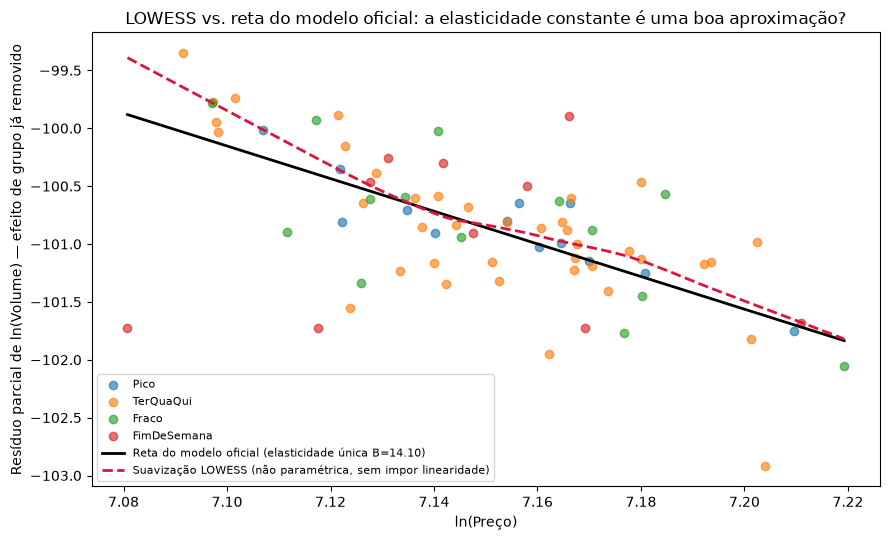

Nota: com N=76 e frac=0.6, o LOWESS aqui é só um diagnóstico visual de linearidade —
não é proposto como modelo alternativo (ver interpretação na célula seguinte).


In [66]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Reaproveita o modelo oficial (modelo_huber4) e a base (m4) já ajustados na seção "Decisão Final de Tratamento"
b_preco_oficial = modelo_huber4.params['ln_Preco']
residuo_parcial = modelo_huber4.resid + b_preco_oficial * m4['ln_Preco']

# frac=0.6 (~46 de 76 pontos por janela local) — amostra pequena exige uma janela ampla
# para o LOWESS não virar puro ruído local
curva_lowess = lowess(residuo_parcial, m4['ln_Preco'], frac=0.6, return_sorted=True)

x_reta = np.linspace(m4['ln_Preco'].min(), m4['ln_Preco'].max(), 100)
intercepto_reta = residuo_parcial.mean() - b_preco_oficial * m4['ln_Preco'].mean()

cores_grupo = {'Pico': 'tab:blue', 'TerQuaQui': 'tab:orange', 'Fraco': 'tab:green', 'FimDeSemana': 'tab:red'}

plt.figure(figsize=(9, 5.5))
for grupo, cor in cores_grupo.items():
    mask = m4['Cluster'] == grupo
    plt.scatter(m4.loc[mask, 'ln_Preco'], residuo_parcial[mask], alpha=0.65, color=cor, label=grupo)

plt.plot(x_reta, intercepto_reta + b_preco_oficial * x_reta, color='black', linewidth=2,
         label=f'Reta do modelo oficial (elasticidade única B={-b_preco_oficial:.2f})')
plt.plot(curva_lowess[:, 0], curva_lowess[:, 1], color='crimson', linewidth=2, linestyle='--',
         label='Suavização LOWESS (não paramétrica, sem impor linearidade)')

plt.xlabel('ln(Preço)')
plt.ylabel('Resíduo parcial de ln(Volume) — efeito de grupo já removido')
plt.title('LOWESS vs. reta do modelo oficial: a elasticidade constante é uma boa aproximação?')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Nota: com N=76 e frac=0.6, o LOWESS aqui é só um diagnóstico visual de linearidade —')
print('não é proposto como modelo alternativo (ver interpretação na célula seguinte).')

### O que o gráfico mostra

Cada ponto é um dia de treino (N=76), colorido pelo grupo de dia (Pico, TerQuaQui, Fraco,
FimDeSemana); o eixo x é `ln(Preço)` e o eixo y é o resíduo parcial de `ln(Volume)` — o volume já
com o efeito de nível de cada grupo removido, sobrando só a variação que o preço explica. As duas
curvas sobrepostas medem essa mesma relação de duas formas diferentes: a **reta preta** é a que o
modelo oficial assume (elasticidade única B=14,10, uma reta em log-log); a **linha vermelha
tracejada** é o LOWESS, que não assume nenhum formato — só segue o que os dados mostram localmente.

**O que se vê no resultado:** as duas curvas ficam próximas ao longo de quase toda a faixa de preço
observada (`ln(Preço)` entre ~7,08 e ~7,22) — a maior distância entre elas é de ~0,2-0,3 na escala do
resíduo, bem menor do que a dispersão dos próprios pontos (que variam quase 3,5 unidades entre o mais
alto e o mais baixo). O LOWESS fica um pouco acima da reta nas duas pontas do preço (queda
ligeiramente menos acentuada do que a reta prevê nos extremos) e praticamente coincide com ela na
região central (`ln(Preço)` ≈ 7,15-7,17), onde também há mais pontos concentrados. Não aparece
nenhuma curvatura em S nem inversão de sinal — a tendência de queda (volume caindo com o preço) é
consistente em toda a faixa. Os grupos de dia (cores) aparecem misturados ao longo de todo o eixo x,
sem se separar em faixas de resíduo diferentes, o que confirma que o efeito de grupo já foi bem
removido antes de plotar.

**Leitura:** a proximidade das duas curvas, com desvios pequenos frente à dispersão dos dados, é
evidência a favor da suposição de elasticidade única e constante que o modelo oficial usa — não há
indício de que uma curva mais flexível (LOWESS, ou um modelo baseado em árvores como LightGBM/XGBoost)
capturaria um padrão real que a reta está perdendo. A leve folga nas pontas de preço é justamente onde
há menos dados (só 2-3 pontos na extremidade esquerda), então é mais plausível que seja ruído de
amostra pequena do que curvatura real — consistente com o Capítulo 11 do relatório, que já mostra a
elasticidade balançando ~15% entre amostras diferentes.

Esta seção **não altera** o modelo campeão nem o pipeline de `src/modeling/demand_curve.py` — é só
uma checagem adicional de robustez da decisão já tomada no Capítulo 12 do relatório.